# Introduction

This notebook assumes you have activated credentials with the CAVE client. CAVE (Connectome Annotation Versioning Engine) is built and supported by a collaboration between the Seung lab at Princeton and the Allen Institute for Brain Science. It allows for programmatic access to the tables associated with Minnie and other datasets. [Github](https://github.com/seung-lab/CAVEclient) 

CAVE setup instructions are [here](https://github.com/AllenInstitute/MicronsBinder/blob/master/notebooks/mm3_intro/CAVEsetup.ipynb).

CAVE tutorial for querying the data is [here](https://github.com/AllenInstitute/MicronsBinder/blob/master/notebooks/mm3_intro/SynapseAndAnnotationQuery.ipynb).

## Using CAVEclient to query data

In [1]:
from caveclient import CAVEclient

Load the public client for accessing the datastack in CAVE. If you have not acquired an authentication token, run the code below to get a new token. You will need to link your Google account.

In [2]:
client = CAVEclient()
client.auth.save_token(token="e4c43e265b8b98779ec2f7c906212703")

# client.auth.get_new_token()

If you have successfully added your token or already have a valid token saved from a previous session, you should be able to initialize the client with the `minnie65_public` datastack:

```python
client = CAVEclient('minnie65_public')
```

If your previous saved token is invalidated, you will need to save your newly acquired token with the argument `overwrite=True`.

```python
client.auth.save_token(token="PASTE_YOUR_TOKEN_HERE", overwrite=True)
```

In [3]:
# this is the datastack name of the public release
# passing it will auto-configure many of the services
client = CAVEclient('minnie65_public')

### Setting the version of the public release

With the initialized client, set the version of the public release:

```python
client.materialize.version = VERSION
```

Table names and data will change between versions. This notebook is built around version `661`. To use a later version, find the corresponding tables in the new version. 

In [4]:
client.materialize.version = 1507

### View available annotation tables

In [5]:
client.materialize.get_tables()

['baylor_gnn_cell_type_fine_model_v2',
 'nucleus_alternative_points',
 'allen_column_mtypes_v2',
 'bodor_pt_cells',
 'aibs_metamodel_mtypes_v661_v2',
 'allen_v1_column_types_slanted_ref',
 'aibs_column_nonneuronal_ref',
 'nucleus_ref_neuron_svm',
 'apl_functional_coreg_vess_fwd',
 'vortex_compartment_targets',
 'baylor_log_reg_cell_type_coarse_v1',
 'gamlin_2023_mcs',
 'l5et_column',
 'pt_synapse_targets',
 'coregistration_manual_v4',
 'cg_cell_type_calls',
 'synapses_pni_2',
 'nucleus_detection_v0',
 'vortex_manual_nodes_of_ranvier',
 'bodor_pt_target_proofread',
 'nucleus_functional_area_assignment',
 'coregistration_auto_phase3_fwd_apl_vess_combined_v2',
 'vortex_thalamic_proofreading_status',
 'multi_input_spine_predictions_ssa',
 'synapse_target_structure',
 'proofreading_status_and_strategy',
 'coregistration_auto_phase3_fwd_v2',
 'vortex_peptidergic_proofreading_status',
 'digital_twin_properties_bcm_coreg_v4',
 'vortex_astrocyte_proofreading_status',
 'digital_twin_properties_b

### Query functionally matched EM neurons

In [5]:
import pandas as pd

# Query both tables
print("Querying coregistration_manual_v4...")
response1 = client.materialize.query_table(
    'coregistration_manual_v4',
    return_df=False
)
coregistration_df = pd.DataFrame(response1)

print("Querying allen_v1_column_types_slanted_ref...")
response2 = client.materialize.query_table(
    'allen_v1_column_types_slanted_ref', 
    return_df=False
)
allen_df = pd.DataFrame(response2)

# Check the columns to confirm pt_root_id exists
print("Coregistration columns:", coregistration_df.columns.tolist())
print("Allen columns:", allen_df.columns.tolist())

# Check data types and sample data
print(f"\nCoregistration shape: {coregistration_df.shape}")
print(f"Allen shape: {allen_df.shape}")

# Join the tables on pt_root_id
matched_df = pd.merge(
    coregistration_df, 
    allen_df, 
    on='pt_root_id', 
    how='inner'  # or 'left', 'right', 'outer' depending on what you want
)

print(f"\nJoined dataframe shape: {matched_df.shape}")
print("Joined columns:", matched_df.columns.tolist())
print(matched_df.head())

Querying coregistration_manual_v4...


Querying allen_v1_column_types_slanted_ref...
Coregistration columns: ['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id', 'id', 'created', 'valid', 'target_id', 'session', 'scan_idx', 'unit_id', 'field', 'residual', 'score']
Allen columns: ['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id', 'id', 'created', 'valid', 'target_id', 'classification_system', 'cell_type']

Coregistration shape: (19181, 25)
Allen shape: (1357, 21)

Joined dataframe shape: (603, 45)
Joined columns: ['id_ref_x', 'created_ref_x', 'valid_ref_x', 'volume_x', 'pt_position_x_x', 'pt_position_y_x'

In [7]:
print(f"Allen DF shape: {allen_df.shape}")
print(f"Coregistration DF shape: {coregistration_df.shape}")
print(f"Matched DF shape: {matched_df.shape}")
print(f"Unique pt_root_id in allen_df: {allen_df['pt_root_id'].nunique()}")
print(f"Unique pt_root_id in coregistration_df: {coregistration_df['pt_root_id'].nunique()}")
print(f"Unique pt_root_id in matched_df: {matched_df['pt_root_id'].nunique()}")

# Check for duplicates
print(f"Duplicates in coregistration_df: {coregistration_df['pt_root_id'].duplicated().sum()}")

Allen DF shape: (1357, 21)
Coregistration DF shape: (19181, 25)
Matched DF shape: (603, 45)
Unique pt_root_id in allen_df: 1357
Unique pt_root_id in coregistration_df: 15434
Unique pt_root_id in matched_df: 490
Duplicates in coregistration_df: 3747


In [9]:
response3 = client.materialize.query_table(
    'proofreading_status_and_strategy',
    return_df=False
)
proof_df = pd.DataFrame(response3)

# proof_df = client.materialize.tables.proofreading_status_and_strategy(status_axon="t").query(
#     select_columns=['pt_root_id','status_axon','status_dendrite','strategy_axon','strategy_dendrite'],
# )
proof_df = proof_df[proof_df["strategy_axon"] == "axon_fully_extended"]

In [10]:
# merge "axon_fully_extended" with match_df
common_cols = set(matched_df.columns) & set(proof_df.columns)
print("Common columns:", common_cols)

# Drop duplicate columns from one DataFrame (except the merge key)
cols_to_drop = [col for col in common_cols if col != 'pt_root_id']
proof_df_clean = proof_df.drop(columns=cols_to_drop)

# Join the tables on pt_root_id
matched_df = pd.merge(
    coregistration_df, 
    proof_df_clean, 
    on='pt_root_id', 
    how='inner'  # or 'left', 'right', 'outer' depending on what you want
)

print(f"\nJoined dataframe shape: {matched_df.shape}")
print("Joined columns:", matched_df.columns.tolist())
print(matched_df.head())

Common columns: {'pt_root_id'}

Joined dataframe shape: (90, 38)
Joined columns: ['id_x', 'created_x', 'valid_x', 'target_id', 'session', 'scan_idx', 'unit_id', 'field', 'residual', 'score', 'id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x_x', 'pt_position_y_x', 'pt_position_z_x', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id_x', 'pt_root_id', 'id_y', 'created_y', 'superceded_id', 'valid_y', 'pt_position_x_y', 'pt_position_y_y', 'pt_position_z_y', 'valid_id', 'status_dendrite', 'status_axon', 'strategy_dendrite', 'strategy_axon', 'pt_supervoxel_id_y']
    id_x      created_x valid_x  target_id  session  scan_idx  unit_id  field  \
0   1958  1716316703391       t     256550        5         6     2243      2   
1   3273  1716316704130       t     222998        5         7     1926      2   
2  17316  1716316962908       t     222998        9         4     2397      2   


In [11]:
matched_df["pt_root_id"]

0     864691136953835487
1     864691135591041291
2     864691135591041291
3     864691136445215875
4     864691135655390658
             ...        
85    864691135258083503
86    864691135273655569
87    864691135617152361
88    864691135938604804
89    864691135105879117
Name: pt_root_id, Length: 90, dtype: int64

In [12]:
myelin = pd.read_csv("myelin_info_df (2).csv")
myelin

,pt_root_id,total_myelin_length,cell_type,number_of_segments
0,864691135938604804,279.49,23P,104
1,864691136578982164,0.00,4P,69
2,864691136196131542,186.98,23P,73
3,864691135572346349,511.41,5P-IT,49
4,864691135699487522,153.43,MC,789
...,...,...,...,...
140,864691135738047620,3.60,5P-IT,87
141,864691135591041291,573.75,23P,114
142,864691135356839887,42.23,5P-IT,59
143,864691136974813212,166.90,5P-IT,77


In [13]:
# Join the tables on pt_root_id
myelin_matched_df = pd.merge(
    matched_df, 
    myelin, 
    on='pt_root_id', 
    how='inner'  # or 'left', 'right', 'outer' depending on what you want
)

print(f"\nJoined dataframe shape: {myelin_matched_df.shape}")
print("Joined columns:", myelin_matched_df.columns.tolist())
myelin_matched_df


Joined dataframe shape: (84, 41)
Joined columns: ['id_x', 'created_x', 'valid_x', 'target_id', 'session', 'scan_idx', 'unit_id', 'field', 'residual', 'score', 'id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x_x', 'pt_position_y_x', 'pt_position_z_x', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id_x', 'pt_root_id', 'id_y', 'created_y', 'superceded_id', 'valid_y', 'pt_position_x_y', 'pt_position_y_y', 'pt_position_z_y', 'valid_id', 'status_dendrite', 'status_axon', 'strategy_dendrite', 'strategy_axon', 'pt_supervoxel_id_y', 'total_myelin_length', 'cell_type', 'number_of_segments']


,id_x,created_x,valid_x,target_id,session,scan_idx,unit_id,field,residual,score,...,pt_position_z_y,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id_y,total_myelin_length,cell_type,number_of_segments
0,1958,1716316703391,t,256550,5,6,2243,2,4.62874,4.76337,...,21422,864691136953835487,t,t,dendrite_extended,axon_fully_extended,89305839907142592,256.70,23P,85
1,3273,1716316704130,t,222998,5,7,1926,2,5.78571,2.09573,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
2,17316,1716316962908,t,222998,9,4,2397,2,3.02052,6.57515,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
3,8901,1716316707276,t,291315,6,7,1602,2,11.80560,-7.54888,...,22028,864691135655390658,t,t,dendrite_extended,axon_fully_extended,90218434691891001,106.26,23P,60
4,8765,1716316707200,t,291175,6,7,1182,2,11.82970,-4.34682,...,21656,864691136674749575,t,t,dendrite_extended,axon_fully_extended,90570209626369807,89.62,23P,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,5958,1716316705635,t,291161,6,4,1606,2,6.22610,5.83200,...,21755,864691135258083503,t,t,dendrite_clean,axon_fully_extended,90148821795140164,3.13,23P,72
80,12606,1716316960321,t,526436,7,4,11409,8,8.89919,4.33921,...,17299,864691135273655569,t,t,dendrite_extended,axon_fully_extended,106554909067292402,1559.00,5P-ET,92
81,4159,1716316704622,t,301095,5,7,7043,6,8.06943,0.22856,...,21255,864691135617152361,t,t,dendrite_extended,axon_fully_extended,90229429674273122,486.63,5P-IT,99
82,14125,1716316961164,t,294539,8,5,2740,2,4.80801,0.93167,...,21266,864691135938604804,t,t,dendrite_extended,axon_fully_extended,89659676492660967,279.49,23P,104


In [14]:
myelin_matched_df[myelin_matched_df["cell_type"] == "BC"]

,id_x,created_x,valid_x,target_id,session,scan_idx,unit_id,field,residual,score,...,pt_position_z_y,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id_y,total_myelin_length,cell_type,number_of_segments


### Column descriptions:

<b>id:</b> a unique identifier for this row

<b>valid:</b> internal check, uniformly ‘t’

<b>pt_supervoxel_id:</b> the ID of the supervoxel from the watershed segmentation that is under the pt_position

<b>pt_root_id:</b> the ID of the segment/root_id under the pt_position from the Proofread Segmentation (v343).

<b>session:</b> the ID indicating the imaging period for the mouse

<b>scan_idx:</b> the index of the scan within the imaging session

<b>unit_id:</b> the ID of the functional ROI (unique per scan)

<b>pt_position_{x,y,z}:</b> the location in 4,4,40 nm voxels at a cell body for the cell

<b>residual:</b> the Euclidean distance between the EM nucleus centroid and the matched functional centroid after the AIBS EM -> 2P coregistration transform

<b>separation:</b> For a matched EM nucleus to a functional unit the separation score is computed as the difference between the residual of the matched pair and the residual of the nearest EM neuronal nucleus that was not matched to the unit.

Note: More confident matches will have a smaller residual and larger separation

### Select a random entry

In [16]:
entry = matched_df.sample(1)
entry

,id_x,created_x,valid_x,target_id,session,scan_idx,unit_id,field,residual,score,...,valid_y,pt_position_x_y,pt_position_y_y,pt_position_z_y,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id_y
78,1204,1716316702973,t,267029,4,7,7981,8,5.87109,8.95811,...,t,173008,205856,20391,864691135503182685,t,t,dendrite_extended,axon_fully_extended,88543328459028709


In [19]:
segment = entry.pt_root_id.values[0] # get ID of segment to visualize
segment
# centroid = entry.pt_position.values[0] # get centroid of segment

864691135503182685

## View entry in Neuroglancer

Programmatic editing of Neuroglancer links can be accomplished using the Seung lab/ AIBS package [nglui](https://github.com/seung-lab/NeuroglancerAnnotationUI).

[Example notebook](https://github.com/seung-lab/NeuroglancerAnnotationUI/blob/master/examples/statebuilder_examples.ipynb)

In [11]:
# generate links in Seung lab a custom Neuroglancer deployment called Neuromancer
from nglui import statebuilder, EasyViewer 

viewer = EasyViewer()
viewer.set_resolution((4,4,40))

em_layer = statebuilder.ImageLayerConfig(client.info.image_source(), 
                                         contrast_controls=True, black=0.35, white=0.7) # set EM layer 
seg_layer =  statebuilder.SegmentationLayerConfig(client.info.segmentation_source(),  
                                                  name='seg', fixed_ids=[segment]) # set dynamic segmentation layer
view_kws = {'layout': '3d',
            'zoom_3d': 3000,
            'position': centroid}  # set zoom options and center on segment

sb = statebuilder.StateBuilder([em_layer, seg_layer], view_kws=view_kws) # generate statebuilder
sb.render_state(return_as='html', base_state=viewer.state) # render state as html link


# Access Functional data

This notebook assumes you have access to a copy of the SQL database that houses the functional data and the functional data schema repository. Instructions to download are [here](https://www.microns-explorer.org/cortical-mm3#f-data).

The contents of the SQL schema are accessed programmatically using [DataJoint](https://datajoint.io/). Find an example notebook for using DataJoint to access the functional data [here](Using_DataJoint_to_Access_Functional_Data.ipynb).

In [6]:
from microns_phase3 import nda, utils
import numpy as np
import matplotlib.pyplot as plt

Connecting microns@db.datajoint.com:3306


### Convert entry to DataJoint compatible key

DataJoint tables can be restricted with dictionaries. Here we generate a dictionary of attributes that specify the unique functional ROI in the DataJoint schema. 

In [20]:
unit_key = entry[['session', 'scan_idx', 'unit_id']].to_dict(orient='records')[0]
unit_key

{'session': 4, 'scan_idx': 7, 'unit_id': 7981}

### Fetch & plot activity trace, calcium trace, pupil radius, and treadmill

Here we use the key to fetch and plot a variety of data from the schema, including the unit's calcium & spike traces, and the scan's pupil trace and treadmill speed. 

Note: The `nda.ManualPupil` and `nda.Treadmill` tables only contain the `session` and `scan_idx` attributes, but can still be retrieved with the `unit_key`. The `unit_id` attribute is ignored when restricting against these tables.

In [26]:
nframes, fps = (nda.Scan & unit_key).fetch1('nframes', 'fps')  # fetch # frames and fps
time_axis = np.arange(nframes)/ fps # create time axis (seconds)
spike_trace = (nda.Activity & unit_key).fetch1('trace') # fetch spike trace
calcium_trace = (nda.ScanUnit * nda.Fluorescence & unit_key).fetch1('trace') # fetch calcium fluorescence trace
pupil_radius = (nda.ManualPupil & unit_key).fetch1('pupil_maj_r') # fetch manually segmented pupil trace 
treadmill = (nda.Treadmill & unit_key).fetch1('treadmill_velocity') # fetch treadmill speed

/usr/local/lib/python3.9/site-packages/datajoint/connection.py:219: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")


In [23]:
nframes, fps

(40000, 6.3009)

In [24]:
time_axis

array([0.00000000e+00, 1.58707486e-01, 3.17414972e-01, ...,
       6.34782333e+03, 6.34798203e+03, 6.34814074e+03])

In [17]:
spike_trace

array([3.0309778e-08, 2.6440217e-08, 2.6329836e-08, ..., 5.4585179e-08,
       3.6866247e-08, 4.1801346e-08], dtype=float32)

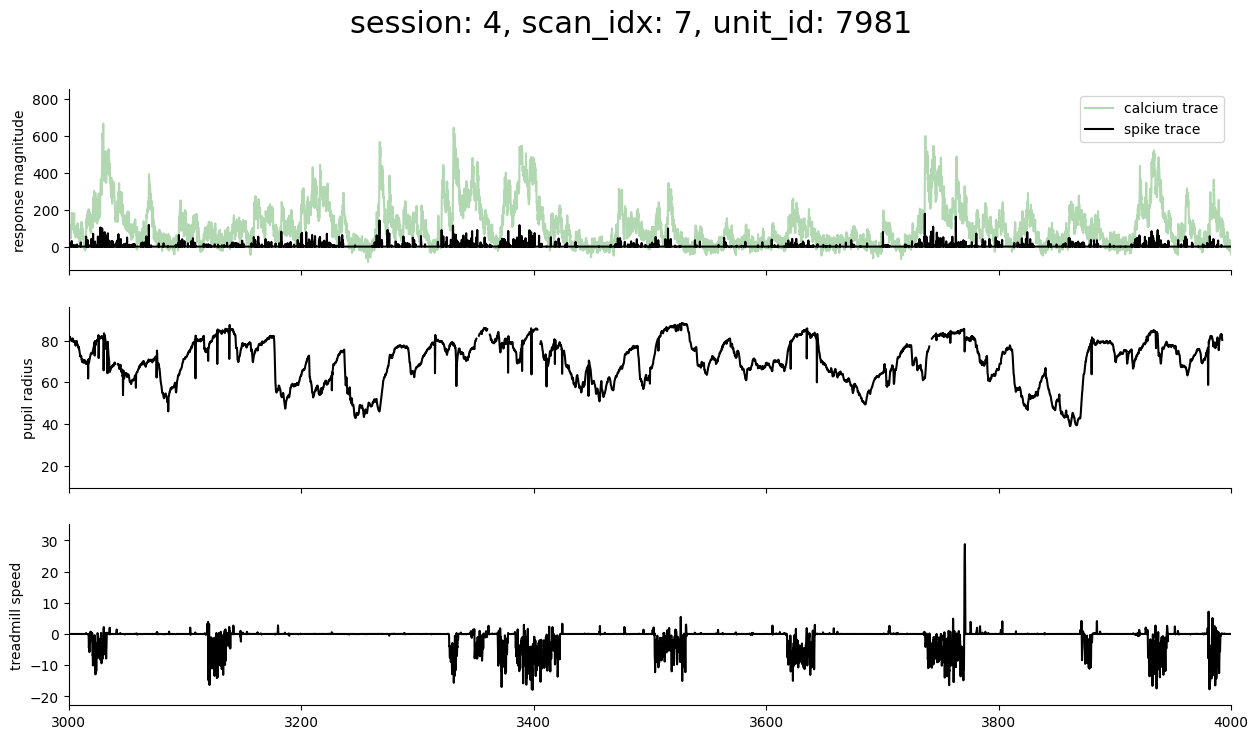

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
ax1.plot(time_axis, calcium_trace, color='g', alpha=0.3, label='calcium trace')
ax1.plot(time_axis, spike_trace, color='k', label='spike trace')
ax2.plot(time_axis, pupil_radius, color='k')
ax3.plot(time_axis, treadmill, color='k')
ax3.set_xlim(3000, 4000) 
ax1.set_ylabel('response magnitude')
ax1.legend()
ax2.set_ylabel('pupil radius')
ax3.set_ylabel('treadmill speed')
fig.suptitle(f'session: {unit_key["session"]}, scan_idx: {unit_key["scan_idx"]}, unit_id: {unit_key["unit_id"]}', fontsize=22);
[ax.spines['right'].set_visible(False) for ax in [ax1, ax2, ax3]];
[ax.spines['top'].set_visible(False) for ax in [ax1, ax2, ax3]];

### Plot oracle raster

Here we use a function provided in the `utils` module to retrieve the responses for the functional unit for the repeated stimulus trials (oracle trials). For a further description of the oracle see the technical documentation.

In [14]:
oracle_traces, score = utils.fetch_oracle_raster(unit_key)

Text(0.5, 1.2, 'session: 6, scan_idx: 6, unit_id: 6198')

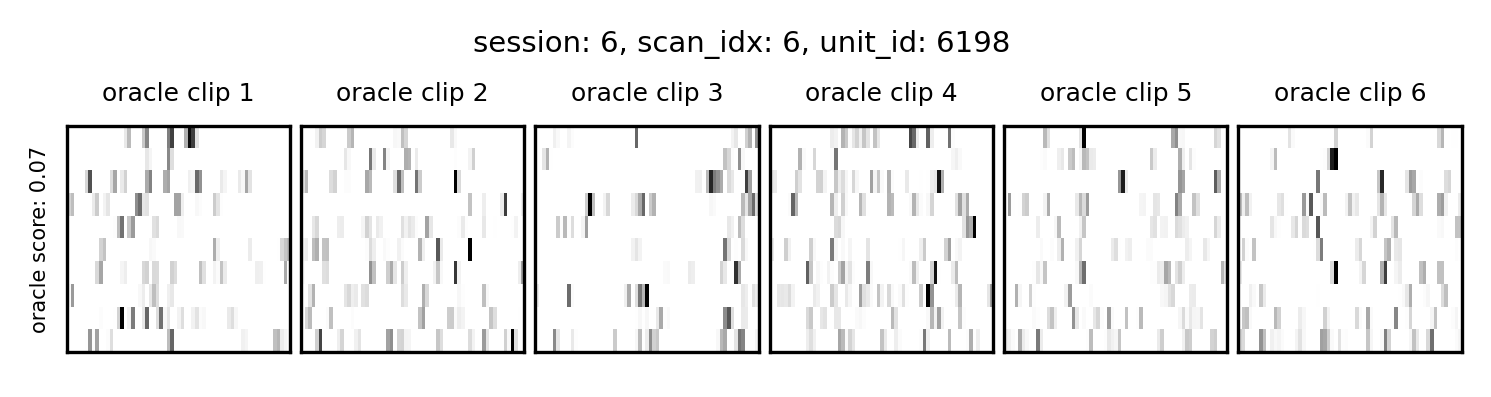

In [15]:
fig,axes = plt.subplots(1,6, figsize=(6,1),dpi=300)
for col,clip_trace in zip(axes,np.moveaxis(oracle_traces,1,0)):
    col.imshow(clip_trace,cmap='binary', interpolation='nearest')
    col.set_aspect('auto')
    col.set_xticks([])
    col.set_yticks([])
axes[0].set_ylabel(f'oracle score: {score:.2f}', fontsize=5)
fig.subplots_adjust(wspace=.05)
[ax.set_title(f'oracle clip {i+1}', fontsize=6) for i, ax in enumerate(axes)];
fig.suptitle(f'session: {unit_key["session"]}, scan_idx: {unit_key["scan_idx"]}, unit_id: {unit_key["unit_id"]}', fontsize=7, y=1.2)

In [21]:
import numpy as np
import scipy.signal as signal
import scipy.stats as stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

def analyze_spike_train(spike_trace, fps, pupil_radius=None, treadmill=None, 
                        spike_threshold=None, bin_size=0.1):
    """
    Comprehensive spike train analysis with behavioral correlates.
    
    Parameters:
    -----------
    spike_trace : array (nframes,)
        Raw spike trace or binary spike train
    fps : float
        Sampling rate in Hz
    pupil_radius : array (nframes,), optional
        Pupil radius trace
    treadmill : array (nframes,), optional
        Treadmill velocity trace
    spike_threshold : float, optional
        Threshold for spike detection if trace is not binary
    bin_size : float
        Bin size in seconds for firing rate calculation
    """
    
    # 1. EXTRACT SPIKE TIMES
    if spike_threshold is not None:
        spike_indices = np.where(spike_trace > spike_threshold)[0]
    else:
        # Assume trace is already binary or spike counts
        spike_indices = np.where(spike_trace > 0)[0]
    
    spike_times = spike_indices / fps  # Convert to seconds
    n_spikes = len(spike_times)
    duration = len(spike_trace) / fps
    
    # 2. BASIC FIRING STATISTICS
    mean_firing_rate = n_spikes / duration
    
    # Inter-spike intervals
    if n_spikes > 1:
        isis = np.diff(spike_times)
        cv_isi = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
        median_isi = np.median(isis)
        
        # Burst detection (ISI < 10ms suggests bursting)
        burst_threshold = 0.01  # 10ms
        burst_isis = isis[isis < burst_threshold]
        burst_fraction = len(burst_isis) / len(isis) if len(isis) > 0 else 0
    else:
        cv_isi = median_isi = burst_fraction = np.nan
    
    # 3. TIME-VARYING FIRING RATE
    # Create binned spike counts
    bin_edges = np.arange(0, duration + bin_size, bin_size)
    spike_counts, _ = np.histogram(spike_times, bins=bin_edges)
    binned_firing_rate = spike_counts / bin_size
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Smooth firing rate (Gaussian kernel, sigma=200ms)
    sigma_samples = int(0.2 * fps / bin_size)  # 200ms in samples
    smooth_firing_rate = gaussian_filter1d(binned_firing_rate, sigma=sigma_samples)
    
    # Fano factor (variance/mean of spike counts)
    fano_factor = np.var(spike_counts) / np.mean(spike_counts) if np.mean(spike_counts) > 0 else np.nan
    
    # 4. BEHAVIORAL STATE ANALYSIS
    behavioral_correlations = {}
    
    if pupil_radius is not None:
        # Correlate firing rate with pupil size (arousal)
        # Downsample firing rate to match original sampling
        fr_resampled = np.interp(np.arange(len(spike_trace))/fps, 
                                  bin_centers, smooth_firing_rate)
        
        # Remove NaNs for correlation
        valid_idx = ~(np.isnan(pupil_radius) | np.isnan(fr_resampled))
        if np.sum(valid_idx) > 10:
            r_pupil, p_pupil = stats.pearsonr(pupil_radius[valid_idx], 
                                               fr_resampled[valid_idx])
            behavioral_correlations['pupil'] = {'r': r_pupil, 'p': p_pupil}
            
            # Split by pupil size (arousal states)
            pupil_median = np.nanmedian(pupil_radius)
            high_arousal_idx = pupil_radius > pupil_median
            low_arousal_idx = pupil_radius <= pupil_median
            
            fr_high_arousal = np.mean(fr_resampled[high_arousal_idx & valid_idx])
            fr_low_arousal = np.mean(fr_resampled[low_arousal_idx & valid_idx])
            arousal_modulation = (fr_high_arousal - fr_low_arousal) / (fr_high_arousal + fr_low_arousal)
            behavioral_correlations['arousal_modulation'] = arousal_modulation
    
    if treadmill is not None:
        # Correlate with locomotion
        fr_resampled = np.interp(np.arange(len(spike_trace))/fps, 
                                  bin_centers, smooth_firing_rate)
        
        valid_idx = ~(np.isnan(treadmill) | np.isnan(fr_resampled))
        if np.sum(valid_idx) > 10:
            r_treadmill, p_treadmill = stats.pearsonr(treadmill[valid_idx], 
                                                        fr_resampled[valid_idx])
            behavioral_correlations['treadmill'] = {'r': r_treadmill, 'p': p_treadmill}
            
            # Split by locomotion state
            movement_threshold = np.nanpercentile(np.abs(treadmill), 75)
            moving_idx = np.abs(treadmill) > movement_threshold
            stationary_idx = np.abs(treadmill) <= movement_threshold
            
            fr_moving = np.mean(fr_resampled[moving_idx & valid_idx])
            fr_stationary = np.mean(fr_resampled[stationary_idx & valid_idx])
            locomotion_modulation = (fr_moving - fr_stationary) / (fr_moving + fr_stationary)
            behavioral_correlations['locomotion_modulation'] = locomotion_modulation
    
    # 5. COMPILE RESULTS
    results = {
        'spike_times': spike_times,
        'n_spikes': n_spikes,
        'mean_firing_rate': mean_firing_rate,
        'cv_isi': cv_isi,
        'median_isi': median_isi,
        'burst_fraction': burst_fraction,
        'fano_factor': fano_factor,
        'binned_firing_rate': binned_firing_rate,
        'smooth_firing_rate': smooth_firing_rate,
        'bin_centers': bin_centers,
        'behavioral_correlations': behavioral_correlations
    }
    
    return results

def plot_spike_analysis(results, spike_trace, calcium_trace, pupil_radius, 
                        treadmill, fps, figsize=(15, 10)):
    """
    Comprehensive visualization of spike analysis results.
    """
    fig, axes = plt.subplots(6, 2, figsize=figsize)
    time_axis = np.arange(len(spike_trace)) / fps
    
    # 1. Raw traces
    ax = axes[0, 0]
    ax.plot(time_axis, spike_trace, 'k', alpha=0.7, label='Spikes')
    ax.set_ylabel('Spike trace')
    ax.set_title(f"Mean FR: {results['mean_firing_rate']:.2f} Hz")
    ax.legend()
    
    ax = axes[1, 0]
    ax.plot(time_axis, calcium_trace, 'g', alpha=0.7, label='Calcium')
    ax.set_ylabel('Calcium (a.u.)')
    
    # 2. Behavioral traces
    ax = axes[2, 0]
    ax.plot(time_axis, pupil_radius, 'b', alpha=0.7)
    ax.set_ylabel('Pupil radius')
    if 'pupil' in results['behavioral_correlations']:
        r = results['behavioral_correlations']['pupil']['r']
        ax.set_title(f"Pupil correlation: r={r:.3f}")
    
    ax = axes[3, 0]
    ax.plot(time_axis, treadmill, 'purple', alpha=0.7)
    ax.set_ylabel('Treadmill velocity')
    if 'treadmill' in results['behavioral_correlations']:
        r = results['behavioral_correlations']['treadmill']['r']
        ax.set_title(f"Locomotion correlation: r={r:.3f}")
    
    # 3. Firing rate
    ax = axes[4, 0]
    ax.plot(results['bin_centers'], results['smooth_firing_rate'], 'r', linewidth=2)
    ax.fill_between(results['bin_centers'], 0, results['smooth_firing_rate'], alpha=0.3)
    ax.set_ylabel('Firing rate (Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_title(f"Fano factor: {results['fano_factor']:.2f}")
    
    # 4. ISI histogram
    ax = axes[0, 1]
    if results['n_spikes'] > 1:
        isis = np.diff(results['spike_times']) * 1000  # Convert to ms
        ax.hist(isis[isis < 100], bins=50, color='gray', alpha=0.7)
        ax.axvline(np.median(isis), color='r', linestyle='--', 
                   label=f"Median: {np.median(isis):.1f}ms")
        ax.set_xlabel('ISI (ms)')
        ax.set_ylabel('Count')
        ax.set_title(f"CV_ISI: {results['cv_isi']:.2f}")
        ax.legend()
    
    # 5. Autocorrelation
    ax = axes[1, 1]
    if results['n_spikes'] > 10:
        # Compute autocorrelation of binned spikes
        from scipy.signal import correlate
        acf = correlate(results['binned_firing_rate'], 
                       results['binned_firing_rate'], mode='same')
        acf = acf / acf[len(acf)//2]  # Normalize
        lags = np.arange(-len(acf)//2, len(acf)//2) * (results['bin_centers'][1] - results['bin_centers'][0])
        center = len(lags)//2
        plot_range = int(2.0 / (results['bin_centers'][1] - results['bin_centers'][0]))  # ±2 seconds
        ax.plot(lags[center-plot_range:center+plot_range], 
                acf[center-plot_range:center+plot_range], 'k')
        ax.axvline(0, color='r', linestyle='--', alpha=0.5)
        ax.set_xlabel('Lag (s)')
        ax.set_ylabel('Autocorrelation')
        ax.set_title('Spike train autocorrelation')
    
    # 6. State-dependent firing
    ax = axes[2, 1]
    if 'arousal_modulation' in results['behavioral_correlations']:
        mod = results['behavioral_correlations']['arousal_modulation']
        ax.bar(['Low arousal', 'High arousal'], 
               [1-mod, 1+mod], color=['blue', 'red'], alpha=0.7)
        ax.set_ylabel('Relative firing rate')
        ax.set_title(f'Arousal modulation: {mod:.3f}')
    
    ax = axes[3, 1]
    if 'locomotion_modulation' in results['behavioral_correlations']:
        mod = results['behavioral_correlations']['locomotion_modulation']
        ax.bar(['Stationary', 'Moving'], 
               [1-mod, 1+mod], color=['gray', 'purple'], alpha=0.7)
        ax.set_ylabel('Relative firing rate')
        ax.set_title(f'Locomotion modulation: {mod:.3f}')
    
    # 7. Scatter plots
    ax = axes[4, 1]
    if 'pupil' in results['behavioral_correlations']:
        # Downsample for scatter plot
        step = max(1, len(spike_trace) // 1000)
        fr_resampled = np.interp(np.arange(len(spike_trace))/fps, 
                                  results['bin_centers'], results['smooth_firing_rate'])
        valid = ~(np.isnan(pupil_radius) | np.isnan(fr_resampled))
        ax.scatter(pupil_radius[::step][valid[::step]], 
                  fr_resampled[::step][valid[::step]], 
                  alpha=0.5, s=1)
        ax.set_xlabel('Pupil radius')
        ax.set_ylabel('Firing rate (Hz)')
    
    ax = axes[5, 0]
    if 'treadmill' in results['behavioral_correlations']:
        step = max(1, len(spike_trace) // 1000)
        fr_resampled = np.interp(np.arange(len(spike_trace))/fps, 
                                  results['bin_centers'], results['smooth_firing_rate'])
        valid = ~(np.isnan(treadmill) | np.isnan(fr_resampled))
        ax.scatter(treadmill[::step][valid[::step]], 
                  fr_resampled[::step][valid[::step]], 
                  alpha=0.5, s=1, color='purple')
        ax.set_xlabel('Treadmill velocity')
        ax.set_ylabel('Firing rate (Hz)')
    
    # Clean up empty subplot
    axes[5, 1].axis('off')
    
    plt.tight_layout()
    return fig

Neuron 4134 Summary:
  Mean firing rate: 0.47 Hz
  CV of ISI: 1.59
  Burst fraction: 0.00%
  Fano factor: 0.95
  Pupil correlation: r=-0.015, p=0.0025
  Arousal modulation: -0.051
  Locomotion correlation: r=0.022, p=0.0000
  Locomotion modulation: -0.075


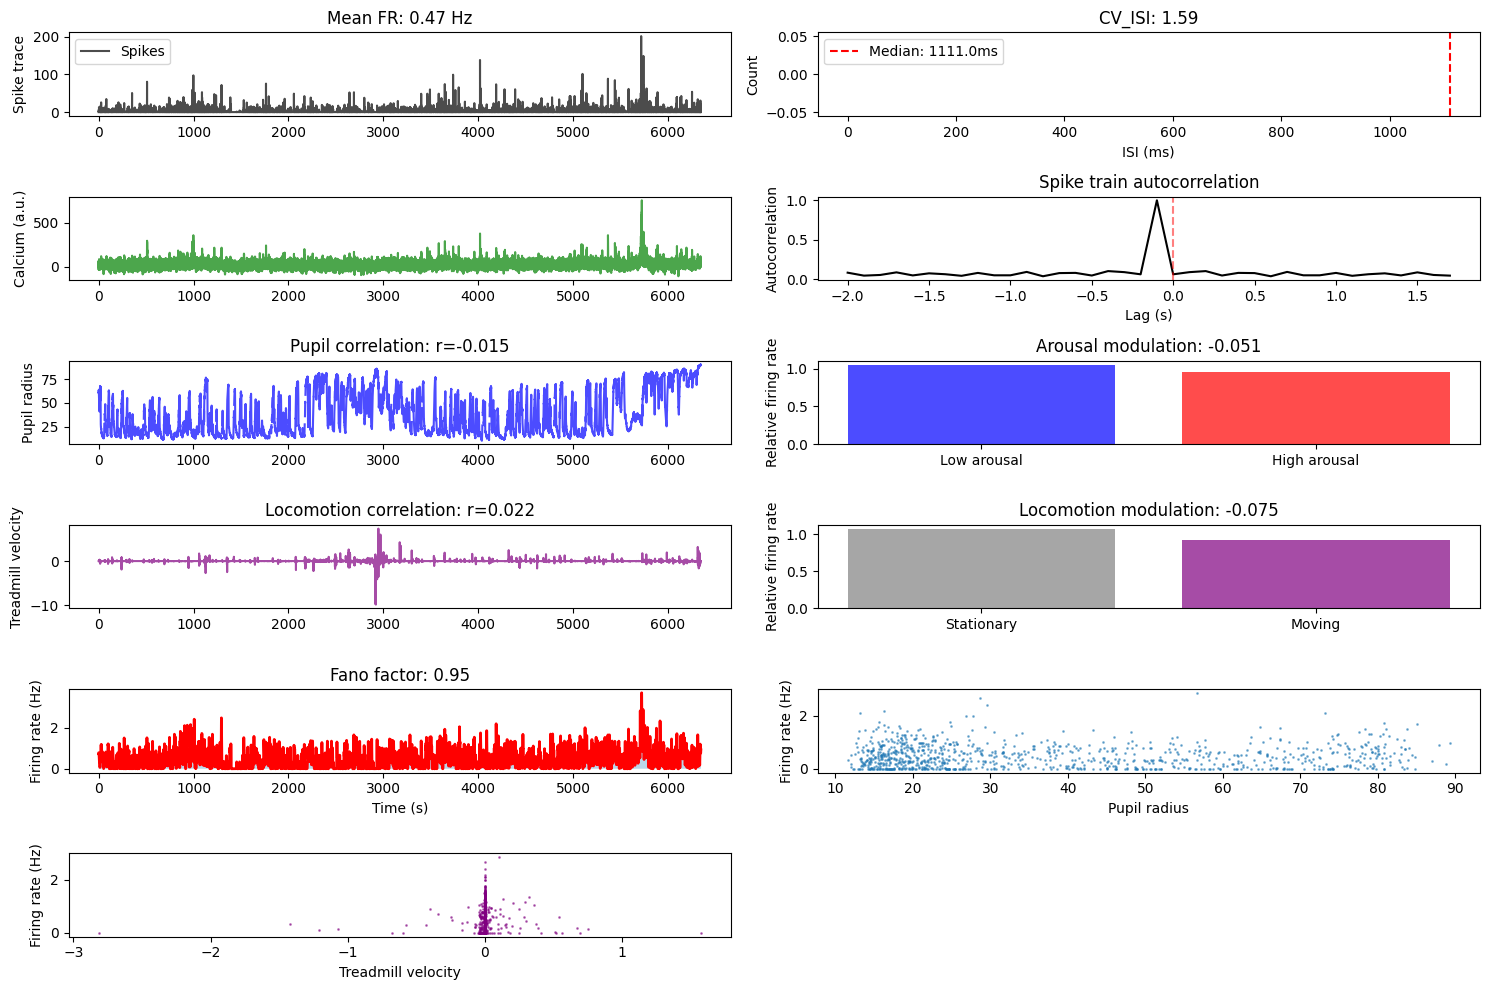

In [23]:

# Run the analysis
results = analyze_spike_train(spike_trace, fps, 
                              pupil_radius=pupil_radius, 
                              treadmill=treadmill,
                              spike_threshold=1)  # Adjust threshold as needed

# Print summary statistics
print(f"Neuron {unit_key['unit_id']} Summary:")
print(f"  Mean firing rate: {results['mean_firing_rate']:.2f} Hz")
print(f"  CV of ISI: {results['cv_isi']:.2f}")
print(f"  Burst fraction: {results['burst_fraction']:.2%}")
print(f"  Fano factor: {results['fano_factor']:.2f}")

if 'pupil' in results['behavioral_correlations']:
    print(f"  Pupil correlation: r={results['behavioral_correlations']['pupil']['r']:.3f}, "
          f"p={results['behavioral_correlations']['pupil']['p']:.4f}")
    print(f"  Arousal modulation: {results['behavioral_correlations']['arousal_modulation']:.3f}")

if 'treadmill' in results['behavioral_correlations']:
    print(f"  Locomotion correlation: r={results['behavioral_correlations']['treadmill']['r']:.3f}, "
          f"p={results['behavioral_correlations']['treadmill']['p']:.4f}")
    print(f"  Locomotion modulation: {results['behavioral_correlations']['locomotion_modulation']:.3f}")

# Create comprehensive visualization
fig = plot_spike_analysis(results, spike_trace, calcium_trace, 
                          pupil_radius, treadmill, fps)
plt.show()


Mean: 0.70
Median: 0.00
99th percentile: 16.04
99.9th percentile: 53.74


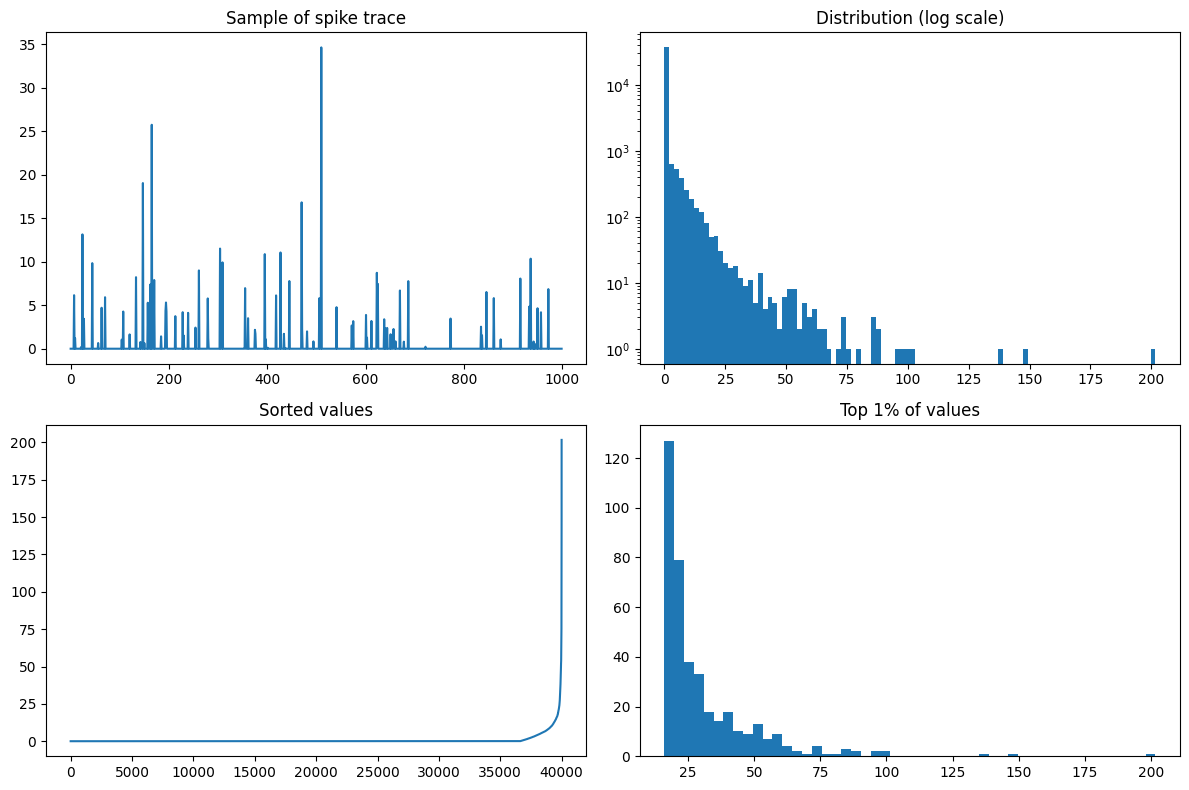

In [31]:
# Let's better understand your data
print(f"Mean: {spike_trace.mean():.2f}")
print(f"Median: {np.median(spike_trace):.2f}")
print(f"99th percentile: {np.percentile(spike_trace, 99):.2f}")
print(f"99.9th percentile: {np.percentile(spike_trace, 99.9):.2f}")

# Plot to see the structure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Time series sample
axes[0,0].plot(spike_trace[:1000])  # First 1000 points
axes[0,0].set_title('Sample of spike trace')

# 2. Histogram on log scale
axes[0,1].hist(spike_trace[spike_trace > 0], bins=100, log=True)
axes[0,1].set_title('Distribution (log scale)')

# 3. Sorted values
axes[1,0].plot(np.sort(spike_trace))
axes[1,0].set_title('Sorted values')

# 4. Zoom on high values
high_vals = spike_trace[spike_trace > np.percentile(spike_trace, 99)]
axes[1,1].hist(high_vals, bins=50)
axes[1,1].set_title('Top 1% of values')

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats

def analyze_deconvolved_spikes(spike_trace, fps, calcium_trace=None, 
                               pupil_radius=None, treadmill=None):
    """
    Analyze deconvolved spike data where values represent spike amplitudes/counts.
    
    Parameters:
    -----------
    spike_trace : array
        Deconvolved spike amplitudes (non-negative continuous values)
    fps : float
        Sampling rate
    """
    
    # Basic statistics
    print("=== Data Summary ===")
    print(f"Mean: {spike_trace.mean():.2f}")
    print(f"Median: {np.median(spike_trace):.2f}")
    print(f"Max: {spike_trace.max():.2f}")
    print(f"Standard deviation: {spike_trace.std():.2f}")
    print(f"99th percentile: {np.percentile(spike_trace, 99):.2f}")
    print(f"99.9th percentile: {np.percentile(spike_trace, 99.9):.2f}")
    
    # Method 1: Threshold-based (any activity above noise floor)
    noise_floor = np.percentile(spike_trace, 50)  # Median as noise estimate
    noise_std = np.median(np.abs(spike_trace - np.median(spike_trace))) * 1.4826
    
    threshold_options = {
        'Above noise': noise_floor + noise_std,
        '2*noise_std': noise_floor + 2*noise_std,
        '3*noise_std': noise_floor + 3*noise_std,
        '95th percentile': np.percentile(spike_trace, 95),
        '99th percentile': np.percentile(spike_trace, 99)
    }
    
    print("\n=== Threshold Options ===")
    for name, thresh in threshold_options.items():
        n_events = np.sum(spike_trace > thresh)
        event_rate = n_events / (len(spike_trace) / fps)
        print(f"{name:20s}: threshold={thresh:6.2f}, events={n_events:5d}, rate={event_rate:.2f} Hz")
    
    # Method 2: Peak detection (for isolated spike events)
    # Fix the distance parameter - must be at least 1
    min_distance = max(1, int(0.002 * fps))  # At least 1 sample, or 2ms if fps allows
    
    # Try different height thresholds for peak detection
    height_thresholds = {
        'median + 2*std': noise_floor + 2*noise_std,
        '90th percentile': np.percentile(spike_trace, 90),
        '95th percentile': np.percentile(spike_trace, 95),
        '99th percentile': np.percentile(spike_trace, 99)
    }
    
    print("\n=== Peak Detection Results ===")
    peak_results = {}
    for name, height in height_thresholds.items():
        if height > 0:  # Only use positive thresholds
            peaks, properties = find_peaks(spike_trace, 
                                          height=height,
                                          distance=min_distance)
            peak_rate = len(peaks) / (len(spike_trace) / fps)
            peak_results[name] = {
                'peaks': peaks,
                'properties': properties,
                'n_peaks': len(peaks),
                'rate': peak_rate
            }
            print(f"{name:20s}: {len(peaks):5d} peaks, {peak_rate:.2f} Hz")
    
    # Method 3: Treat as continuous rate/probability
    # Integrate activity over time windows
    window_ms = 100  # 100ms bins
    window_samples = max(1, int(window_ms * fps / 1000))
    
    # Reshape and sum over windows (handle edge cases)
    n_windows = len(spike_trace) // window_samples
    truncated_trace = spike_trace[:n_windows * window_samples]
    binned_activity = truncated_trace.reshape(n_windows, window_samples).sum(axis=1)
    
    # Convert to firing rate
    binned_rate = binned_activity / (window_ms / 1000)  # Convert to Hz
    
    print(f"\n=== Integrated Activity (100ms bins) ===")
    print(f"Mean rate: {binned_rate.mean():.2f} Hz")
    print(f"Max rate: {binned_rate.max():.2f} Hz")
    print(f"Active bins: {np.sum(binned_rate > 0)} / {n_windows}")
    
    # Visualization
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    
    # 1. Sample trace with different interpretations
    ax = axes[0, 0]
    sample_end = min(int(5 * fps), len(spike_trace))  # 5 seconds
    time_sample = np.arange(sample_end) / fps
    ax.plot(time_sample, spike_trace[:sample_end], 'k-', alpha=0.7, linewidth=0.5)
    
    # Show peaks using 95th percentile
    best_height = np.percentile(spike_trace, 95)
    peaks_sample, _ = find_peaks(spike_trace[:sample_end], 
                                 height=best_height, 
                                 distance=min_distance)
    ax.scatter(peaks_sample/fps, spike_trace[peaks_sample], 
              color='r', s=30, zorder=5, label='Detected peaks')
    ax.axhline(best_height, color='r', linestyle='--', alpha=0.5, label=f'Threshold: {best_height:.1f}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title('Sample trace with peak detection')
    ax.legend()
    
    # 2. Distribution on log scale
    ax = axes[0, 1]
    nonzero_vals = spike_trace[spike_trace > 0]
    if len(nonzero_vals) > 0:
        ax.hist(nonzero_vals, bins=100, log=True, alpha=0.7, color='blue')
        ax.axvline(np.median(nonzero_vals), color='r', linestyle='--', label='Median')
        ax.axvline(np.percentile(spike_trace, 95), color='g', linestyle='--', label='95th %ile')
        ax.set_xlabel('Amplitude')
        ax.set_ylabel('Count (log scale)')
        ax.set_title('Distribution of non-zero values')
        ax.legend()
    
    # 3. Cumulative distribution
    ax = axes[0, 2]
    sorted_vals = np.sort(spike_trace)
    cumulative = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, cumulative)
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Cumulative probability')
    ax.set_title('CDF of spike amplitudes')
    ax.grid(True, alpha=0.3)
    
    # 4. Time-varying firing rate
    ax = axes[1, 0]
    time_bins = np.arange(n_windows) * (window_ms / 1000)
    ax.plot(time_bins, binned_rate, 'k-', alpha=0.7)
    ax.fill_between(time_bins, 0, binned_rate, alpha=0.3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Rate (Hz)')
    ax.set_title('Integrated firing rate (100ms bins)')
    
    # 5. Spike amplitude vs time (scatter)
    ax = axes[1, 1]
    # Downsample for visualization
    spike_times = np.where(spike_trace > np.percentile(spike_trace, 95))[0]
    if len(spike_times) > 0:
        ax.scatter(spike_times[:1000]/fps, spike_trace[spike_times[:1000]], 
                  s=5, alpha=0.5, c=spike_trace[spike_times[:1000]], cmap='hot')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Spike amplitude')
        ax.set_title('Spike amplitudes over time')
        ax.set_xlim([0, min(len(spike_trace)/fps, spike_times[:1000][-1]/fps + 1)])
    
    # 6. ISI distribution (if using peak detection)
    ax = axes[1, 2]
    best_result = peak_results.get('95th percentile', list(peak_results.values())[0])
    if best_result['n_peaks'] > 1:
        peak_times = best_result['peaks'] / fps
        isis = np.diff(peak_times) * 1000  # Convert to ms
        ax.hist(isis[isis < 500], bins=50, alpha=0.7, color='gray')
        ax.axvline(np.median(isis), color='r', linestyle='--', 
                  label=f'Median: {np.median(isis):.1f}ms')
        ax.set_xlabel('ISI (ms)')
        ax.set_ylabel('Count')
        ax.set_title('Inter-spike intervals')
        ax.legend()
    
    # 7. Correlation with calcium (if available)
    if calcium_trace is not None:
        ax = axes[2, 0]
        # Smooth both traces for correlation
        from scipy.ndimage import gaussian_filter1d
        sigma = max(1, int(0.1 * fps))  # 100ms smoothing, minimum 1 sample
        spike_smooth = gaussian_filter1d(spike_trace, sigma)
        calcium_smooth = gaussian_filter1d(calcium_trace, sigma)
        
        # Compute correlation at different lags
        max_lag_s = 2  # seconds
        max_lag = int(max_lag_s * fps)
        lags = np.arange(-max_lag, max_lag)
        correlations = []
        
        for lag in lags[::10]:  # Downsample for speed
            if lag < 0:
                corr, _ = stats.pearsonr(spike_smooth[:lag], calcium_smooth[-lag:])
            elif lag > 0:
                corr, _ = stats.pearsonr(spike_smooth[lag:], calcium_smooth[:-lag])
            else:
                corr, _ = stats.pearsonr(spike_smooth, calcium_smooth)
            correlations.append(corr)
        
        ax.plot(lags[::10]/fps, correlations, 'b-')
        ax.axvline(0, color='r', linestyle='--', alpha=0.5)
        ax.set_xlabel('Lag (s)')
        ax.set_ylabel('Correlation')
        ax.set_title('Spike-Calcium cross-correlation')
        ax.grid(True, alpha=0.3)
    else:
        axes[2, 0].axis('off')
    
    # 8. Behavioral correlation (if available)
    if pupil_radius is not None:
        ax = axes[2, 1]
        # Bin both signals
        n_bins = min(len(pupil_radius), len(spike_trace)) // window_samples
        pupil_binned = pupil_radius[:n_bins * window_samples].reshape(n_bins, window_samples).mean(axis=1)
        rate_binned = binned_rate[:n_bins]
        
        valid = ~(np.isnan(pupil_binned) | np.isnan(rate_binned))
        if np.sum(valid) > 10:
            ax.scatter(pupil_binned[valid], rate_binned[valid], alpha=0.5, s=5)
            ax.set_xlabel('Pupil radius')
            ax.set_ylabel('Firing rate (Hz)')
            ax.set_title('Pupil vs firing rate')
            
            # Add correlation
            r, p = stats.pearsonr(pupil_binned[valid], rate_binned[valid])
            ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3e}', 
                   transform=ax.transAxes, verticalalignment='top')
    else:
        axes[2, 1].axis('off')
    
    # 9. Summary text
    ax = axes[2, 2]
    ax.axis('off')
    
    summary_text = "=== RECOMMENDATIONS ===\n\n"
    summary_text += "This appears to be deconvolved spike data\n"
    summary_text += "where values represent spike amplitudes.\n\n"
    
    summary_text += "Suggested approach:\n"
    if binned_rate.mean() > 0.1 and binned_rate.mean() < 50:
        summary_text += f"• Use integrated rate: {binned_rate.mean():.2f} Hz\n"
    
    if best_result['rate'] > 0.1 and best_result['rate'] < 50:
        summary_text += f"• Or detect peaks: {best_result['rate']:.2f} Hz\n"
        summary_text += f"  (using 95th percentile threshold)\n"
    
    summary_text += f"\nNon-zero timepoints: {(spike_trace > 0).sum()}\n"
    summary_text += f"Significant events (>95%): {(spike_trace > np.percentile(spike_trace, 95)).sum()}"
    
    ax.text(0.1, 0.5, summary_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='center', family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Return results
    return {
        'noise_floor': noise_floor,
        'noise_std': noise_std,
        'threshold_options': threshold_options,
        'peak_results': peak_results,
        'binned_rate': binned_rate,
        'mean_rate': binned_rate.mean(),
        'recommended_threshold': np.percentile(spike_trace, 95)
    }

=== Data Summary ===
Mean: 0.70
Median: 0.00
Max: 201.72
Standard deviation: 4.04
99th percentile: 16.04
99.9th percentile: 53.74

=== Threshold Options ===
Above noise         : threshold=  0.00, events=12371, rate=1.95 Hz
2*noise_std         : threshold=  0.00, events= 9293, rate=1.46 Hz
3*noise_std         : threshold=  0.00, events= 7689, rate=1.21 Hz
95th percentile     : threshold=  4.01, events= 2000, rate=0.32 Hz
99th percentile     : threshold= 16.04, events=  400, rate=0.06 Hz

=== Peak Detection Results ===
median + 2*std      :  3921 peaks, 0.62 Hz
90th percentile     :  2997 peaks, 0.47 Hz
95th percentile     :  1789 peaks, 0.28 Hz
99th percentile     :   348 peaks, 0.05 Hz

=== Integrated Activity (100ms bins) ===
Mean rate: 7.02 Hz
Max rate: 2017.18 Hz
Active bins: 39568 / 40000


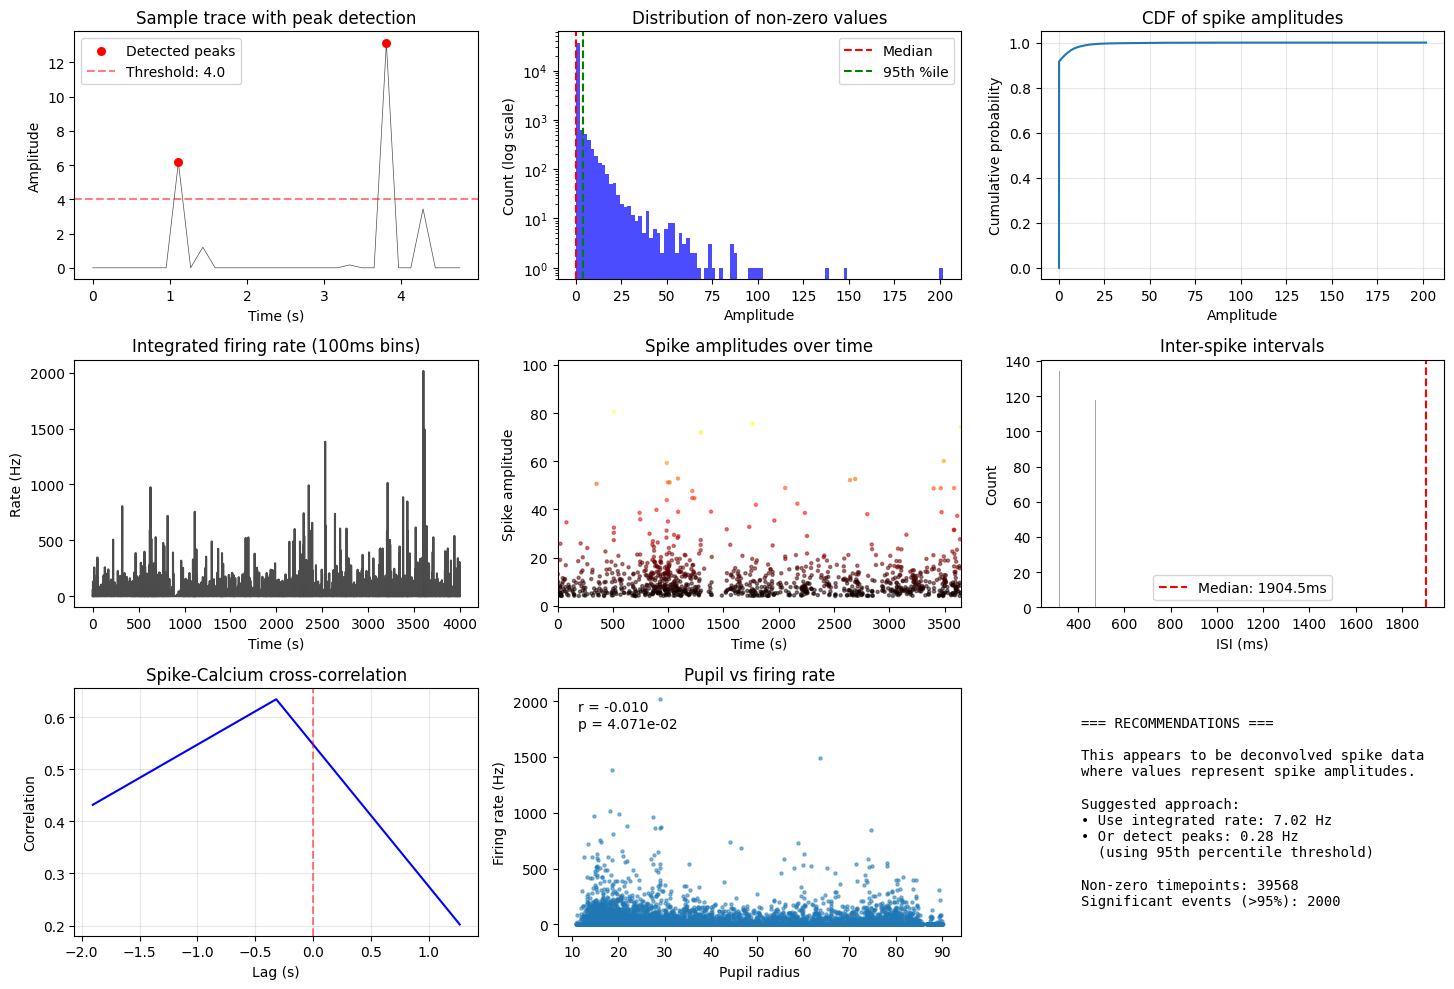

Detected 2000 spike events
Mean firing rate: 7.02 Hz


In [37]:

results = analyze_deconvolved_spikes(spike_trace, fps, 
                                     calcium_trace=calcium_trace,
                                     pupil_radius=pupil_radius, 
                                     treadmill=treadmill)

# Use the recommended approach
threshold = results['recommended_threshold']
spike_events = spike_trace > threshold
print(f"Detected {spike_events.sum()} spike events")
print(f"Mean firing rate: {results['mean_rate']:.2f} Hz")

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from tqdm import tqdm

def quantify_neuron(unit_key, nda):
    """Quantify activity for a single neuron."""
    try:
        # Fetch data
        nframes, fps = (nda.Scan & unit_key).fetch1('nframes', 'fps')
        spike_trace = (nda.Activity & unit_key).fetch1('trace')
        calcium_trace = (nda.ScanUnit * nda.Fluorescence & unit_key).fetch1('trace')
        
        # Basic metrics
        duration = nframes / fps
        
        # Integrated firing rate (100ms bins)
        bin_samples = max(1, int(0.1 * fps))
        n_bins = len(spike_trace) // bin_samples
        binned = spike_trace[:n_bins * bin_samples].reshape(n_bins, bin_samples).sum(axis=1)
        firing_rate = (binned / 0.1).mean()  # Hz
        
        # Peak detection for significant events
        threshold = np.percentile(spike_trace, 95)
        peaks, _ = find_peaks(spike_trace, height=threshold, distance=max(1, int(0.002*fps)))
        n_spikes = len(peaks)
        peak_rate = n_spikes / duration
        
        # Variability metrics
        cv = binned.std() / (binned.mean() + 1e-10)
        fano = binned.var() / (binned.mean() + 1e-10)
        
        # Calcium correlation
        sigma = max(1, int(0.05 * fps))
        spike_smooth = gaussian_filter1d(spike_trace, sigma)
        calcium_smooth = gaussian_filter1d(calcium_trace, sigma)
        correlation = np.corrcoef(spike_smooth, calcium_smooth)[0, 1]
        
        return {
            'unit_id': unit_key['unit_id'],
            'session': unit_key['session'],
            'scan_idx': unit_key['scan_idx'],
            'firing_rate': firing_rate,
            'n_events': n_spikes,
            'event_rate': peak_rate,
            'cv': cv,
            'fano_factor': fano,
            'ca_correlation': correlation,
            'mean_amplitude': spike_trace.mean(),
            'max_amplitude': spike_trace.max(),
            'active_fraction': (spike_trace > 0).mean()
        }
    except Exception as e:
        print(f"Error processing unit {unit_key}: {e}")
        return None

def analyze_population(matched_df, nda, sample_size=None):
    """Analyze all neurons in matched_df."""
    
    # Sample if requested
    df = matched_df.sample(n=sample_size) if sample_size else matched_df
    
    results = []
    for _, entry in tqdm(df.iterrows(), total=len(df), desc="Processing neurons"):
        unit_key = entry[['session', 'scan_idx', 'unit_id']].to_dict()
        result = quantify_neuron(unit_key, nda)
        if result:
            result['pt_root_id'] = entry.pt_root_id
            results.append(result)
    
    return pd.DataFrame(results)

def plot_population_summary(results_df, figsize=(15, 10)):
    """Create summary plots for population analysis."""
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # 1. Firing rate distribution
    ax = axes[0, 0]
    ax.hist(results_df['firing_rate'], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(results_df['firing_rate'].median(), color='r', linestyle='--', 
               label=f'Median: {results_df["firing_rate"].median():.2f} Hz')
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('# Neurons')
    ax.set_title('Firing Rate Distribution')
    ax.legend()
    
    # 2. Events vs Firing Rate
    ax = axes[0, 1]
    sc = ax.scatter(results_df['firing_rate'], results_df['event_rate'], 
                    c=results_df['ca_correlation'], cmap='viridis', alpha=0.6)
    ax.set_xlabel('Integrated Rate (Hz)')
    ax.set_ylabel('Peak Event Rate (Hz)')
    ax.set_title('Rate Comparison')
    plt.colorbar(sc, ax=ax, label='Ca correlation')
    
    # 3. CV vs Fano Factor
    ax = axes[0, 2]
    ax.scatter(results_df['cv'], results_df['fano_factor'], alpha=0.6)
    ax.set_xlabel('CV')
    ax.set_ylabel('Fano Factor')
    ax.set_title('Variability Metrics')
    ax.axline((0, 0), slope=1, color='r', linestyle='--', alpha=0.5)
    
    # 4. Calcium correlation distribution
    ax = axes[1, 0]
    ax.hist(results_df['ca_correlation'], bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(0.5, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spike-Calcium Correlation')
    ax.set_ylabel('# Neurons')
    ax.set_title('Calcium Correlation Quality')
    
    # 5. Active fraction vs firing rate
    ax = axes[1, 1]
    ax.scatter(results_df['active_fraction'], results_df['firing_rate'], alpha=0.6)
    ax.set_xlabel('Active Fraction')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.set_title('Activity vs Sparsity')
    
    # 6. Summary statistics
    ax = axes[1, 2]
    ax.axis('off')
    
    stats_text = f"""Population Summary (n={len(results_df)}):
    
Firing Rate:
  Mean: {results_df['firing_rate'].mean():.2f} Hz
  Median: {results_df['firing_rate'].median():.2f} Hz
  Range: {results_df['firing_rate'].min():.2f} - {results_df['firing_rate'].max():.2f} Hz

Events:
  Mean: {results_df['n_events'].mean():.0f} events
  Total: {results_df['n_events'].sum():.0f} events

Calcium Correlation:
  Mean: {results_df['ca_correlation'].mean():.3f}
  Good (>0.5): {(results_df['ca_correlation'] > 0.5).sum()} neurons

Active Neurons (>1 Hz): {(results_df['firing_rate'] > 1).sum()}
Silent Neurons (<0.1 Hz): {(results_df['firing_rate'] < 0.1).sum()}"""
    
    ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='center', family='monospace')
    
    plt.tight_layout()
    return fig

# Quick comparison function
def compare_neurons(results_df, neuron_ids=None, metric='firing_rate'):
    """Quick comparison of specific neurons."""
    if neuron_ids:
        subset = results_df[results_df['unit_id'].isin(neuron_ids)]
    else:
        subset = results_df
    
    return subset.sort_values(metric, ascending=False)[['unit_id', 'firing_rate', 
                                                         'n_events', 'cv', 
                                                         'ca_correlation']].head(20)

In [ ]:
# Run analysis
# results_df = analyze_population(matched_df, nda, sample_size=100)
results_df = analyze_population(myelin_matched_df, nda)

# Find top firing neurons with their IDs
top_firing = results_df.nlargest(10, 'firing_rate')[['pt_root_id', 'firing_rate', 'ca_correlation']]
print(top_firing)

# Find most variable neurons
most_variable = results_df.nlargest(10, 'cv')[['pt_root_id', 'cv', 'firing_rate']]

# Find specific neuron by pt_root_id
# neuron_id = 864691135874038333  # example
# neuron = results_df[results_df['pt_root_id'] == neuron_id]

Processing neurons:   0%|          | 0/69 [00:00<?, ?it/s]/usr/local/lib/python3.9/site-packages/datajoint/connection.py:219: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")
Processing neurons: 100%|██████████| 69/69 [01:56<00:00,  1.69s/it]

            pt_root_id  firing_rate  ca_correlation
8   864691136052828915    57.990105        0.498428
10  864691136144674612    55.507664        0.496769
54  864691135155894884    50.608486        0.466912
21  864691136390474359    48.141186        0.485617
5   864691135325071004    46.675339        0.483630
55  864691135701676411    32.595638        0.473405
0   864691136953835487    28.957438        0.471247
7   864691135447638356    25.204782        0.521505
11  864691136144674612    24.659929        0.487173
40  864691135855890478    24.576357        0.485492


In [33]:
# Final results merge with myelin
myelin_results_df = pd.merge(
    results_df, 
    myelin_matched_df, 
    on='pt_root_id', 
    how='inner'  # or 'left', 'right', 'outer' depending on what you want
)

print(f"Unique pt_root_id in myelin_results_df: {myelin_results_df['pt_root_id'].nunique()}")
print(f"Unique pt_root_id in myelin_matched_df: {myelin_matched_df['pt_root_id'].nunique()}")
print(f"Unique pt_root_id in results_df: {results_df['pt_root_id'].nunique()}")

myelin_results_df

Unique pt_root_id in myelin_results_df: 54
Unique pt_root_id in myelin_matched_df: 54
Unique pt_root_id in results_df: 54


,unit_id_x,session_x,scan_idx_x,firing_rate,n_events,event_rate,cv,fano_factor,ca_correlation,mean_amplitude,...,pt_position_z_y,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id_y,total_myelin_length,cell_type,number_of_segments
0,2243,5,6,28.957438,1558,0.245420,6.255913,113.329105,0.471247,2.895744,...,21422,864691136953835487,t,t,dendrite_extended,axon_fully_extended,89305839907142592,256.70,23P,85
1,1926,5,7,19.392170,1713,0.269836,5.001755,48.514469,0.495318,1.939217,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
2,1926,5,7,19.392170,1713,0.269836,5.001755,48.514469,0.495318,1.939217,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
3,2397,9,4,17.866085,2029,0.349700,6.286696,70.611331,0.470363,1.786608,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
4,2397,9,4,17.866085,2029,0.349700,6.286696,70.611331,0.470363,1.786608,...,22997,864691135591041291,t,t,dendrite_extended,axon_fully_extended,86913165367478600,573.75,23P,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,1606,6,4,9.288512,1666,0.262432,7.888808,57.805476,0.475128,0.928851,...,21755,864691135258083503,t,t,dendrite_clean,axon_fully_extended,90148821795140164,3.13,23P,72
95,11409,7,4,4.937127,1768,0.278500,5.878837,17.063074,0.426396,0.493713,...,17299,864691135273655569,t,t,dendrite_extended,axon_fully_extended,106554909067292402,1559.00,5P-ET,92
96,7043,5,7,14.890231,1565,0.246523,6.356717,60.168223,0.499908,1.489023,...,21255,864691135617152361,t,t,dendrite_extended,axon_fully_extended,90229429674273122,486.63,5P-IT,99
97,2740,8,5,17.248466,1604,0.252666,6.190828,66.107085,0.495449,1.724847,...,21266,864691135938604804,t,t,dendrite_extended,axon_fully_extended,89659676492660967,279.49,23P,104


In [26]:
results_df

,unit_id,session,scan_idx,firing_rate,n_events,event_rate,cv,fano_factor,ca_correlation,mean_amplitude,max_amplitude,active_fraction,pt_root_id
0,2243,5,6,28.957438,1558,0.245420,6.255913,113.329105,0.471247,2.895744,559.109680,0.995750,864691136953835487
1,1926,5,7,19.392170,1713,0.269836,5.001755,48.514469,0.495318,1.939217,274.637512,0.986050,864691135591041291
2,2397,9,4,17.866085,2029,0.349700,6.286696,70.611331,0.470363,1.786608,458.647003,0.982920,864691135591041291
3,1602,6,7,8.006992,1692,0.266528,5.873494,27.622475,0.468273,0.800699,152.149551,0.998550,864691135655390658
4,1182,6,7,6.001889,1747,0.275192,5.485381,18.059328,0.458185,0.600189,97.091225,0.999175,864691136674749575
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1606,6,4,9.288512,1666,0.262432,7.888808,57.805476,0.475128,0.928851,314.888824,0.991950,864691135258083503
65,11409,7,4,4.937127,1768,0.278500,5.878837,17.063074,0.426396,0.493713,117.203094,0.997850,864691135273655569
66,7043,5,7,14.890231,1565,0.246523,6.356717,60.168223,0.499908,1.489023,294.146027,0.994775,864691135617152361
67,2740,8,5,17.248466,1604,0.252666,6.190828,66.107085,0.495449,1.724847,528.696838,0.998975,864691135938604804


In [17]:
myelin_results_df
myelin_results_df[['pt_root_id', 'firing_rate', 'n_events', 'event_rate', 'ca_correlation', 'total_myelin_length', 'cell_type']].to_csv('neuron_ids_activity.csv')

NameError: name 'myelin_results_df' is not defined

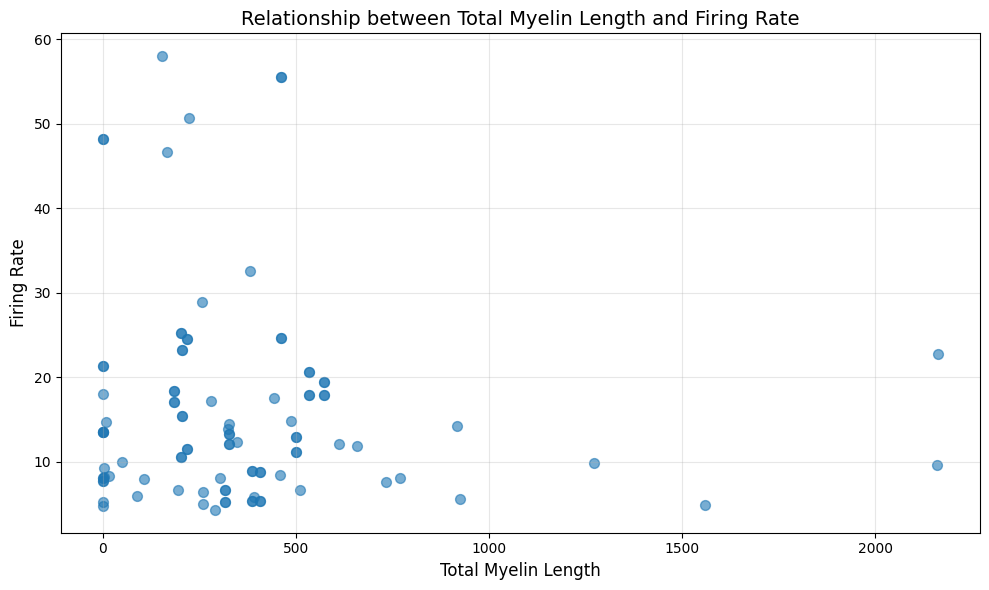

Data Summary:
Number of neurons: 99

Total Myelin Length - Min: 0.00, Max: 2163.25
Firing Rate - Min: 4.31, Max: 57.99

Correlation coefficient: -0.082


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('neuron_ids_activity.csv')

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df['total_myelin_length'], df['firing_rate'], alpha=0.6, s=50)

# Add labels and title
plt.xlabel('Total Myelin Length', fontsize=12)
plt.ylabel('Firing Rate', fontsize=12)
plt.title('Relationship between Total Myelin Length and Firing Rate', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Display the plot
plt.tight_layout()
plt.show()

# Optional: Print basic statistics
print("Data Summary:")
print(f"Number of neurons: {len(df)}")
print(f"\nTotal Myelin Length - Min: {df['total_myelin_length'].min():.2f}, Max: {df['total_myelin_length'].max():.2f}")
print(f"Firing Rate - Min: {df['firing_rate'].min():.2f}, Max: {df['firing_rate'].max():.2f}")

# Optional: Calculate correlation
correlation = df['total_myelin_length'].corr(df['firing_rate'])
print(f"\nCorrelation coefficient: {correlation:.3f}")

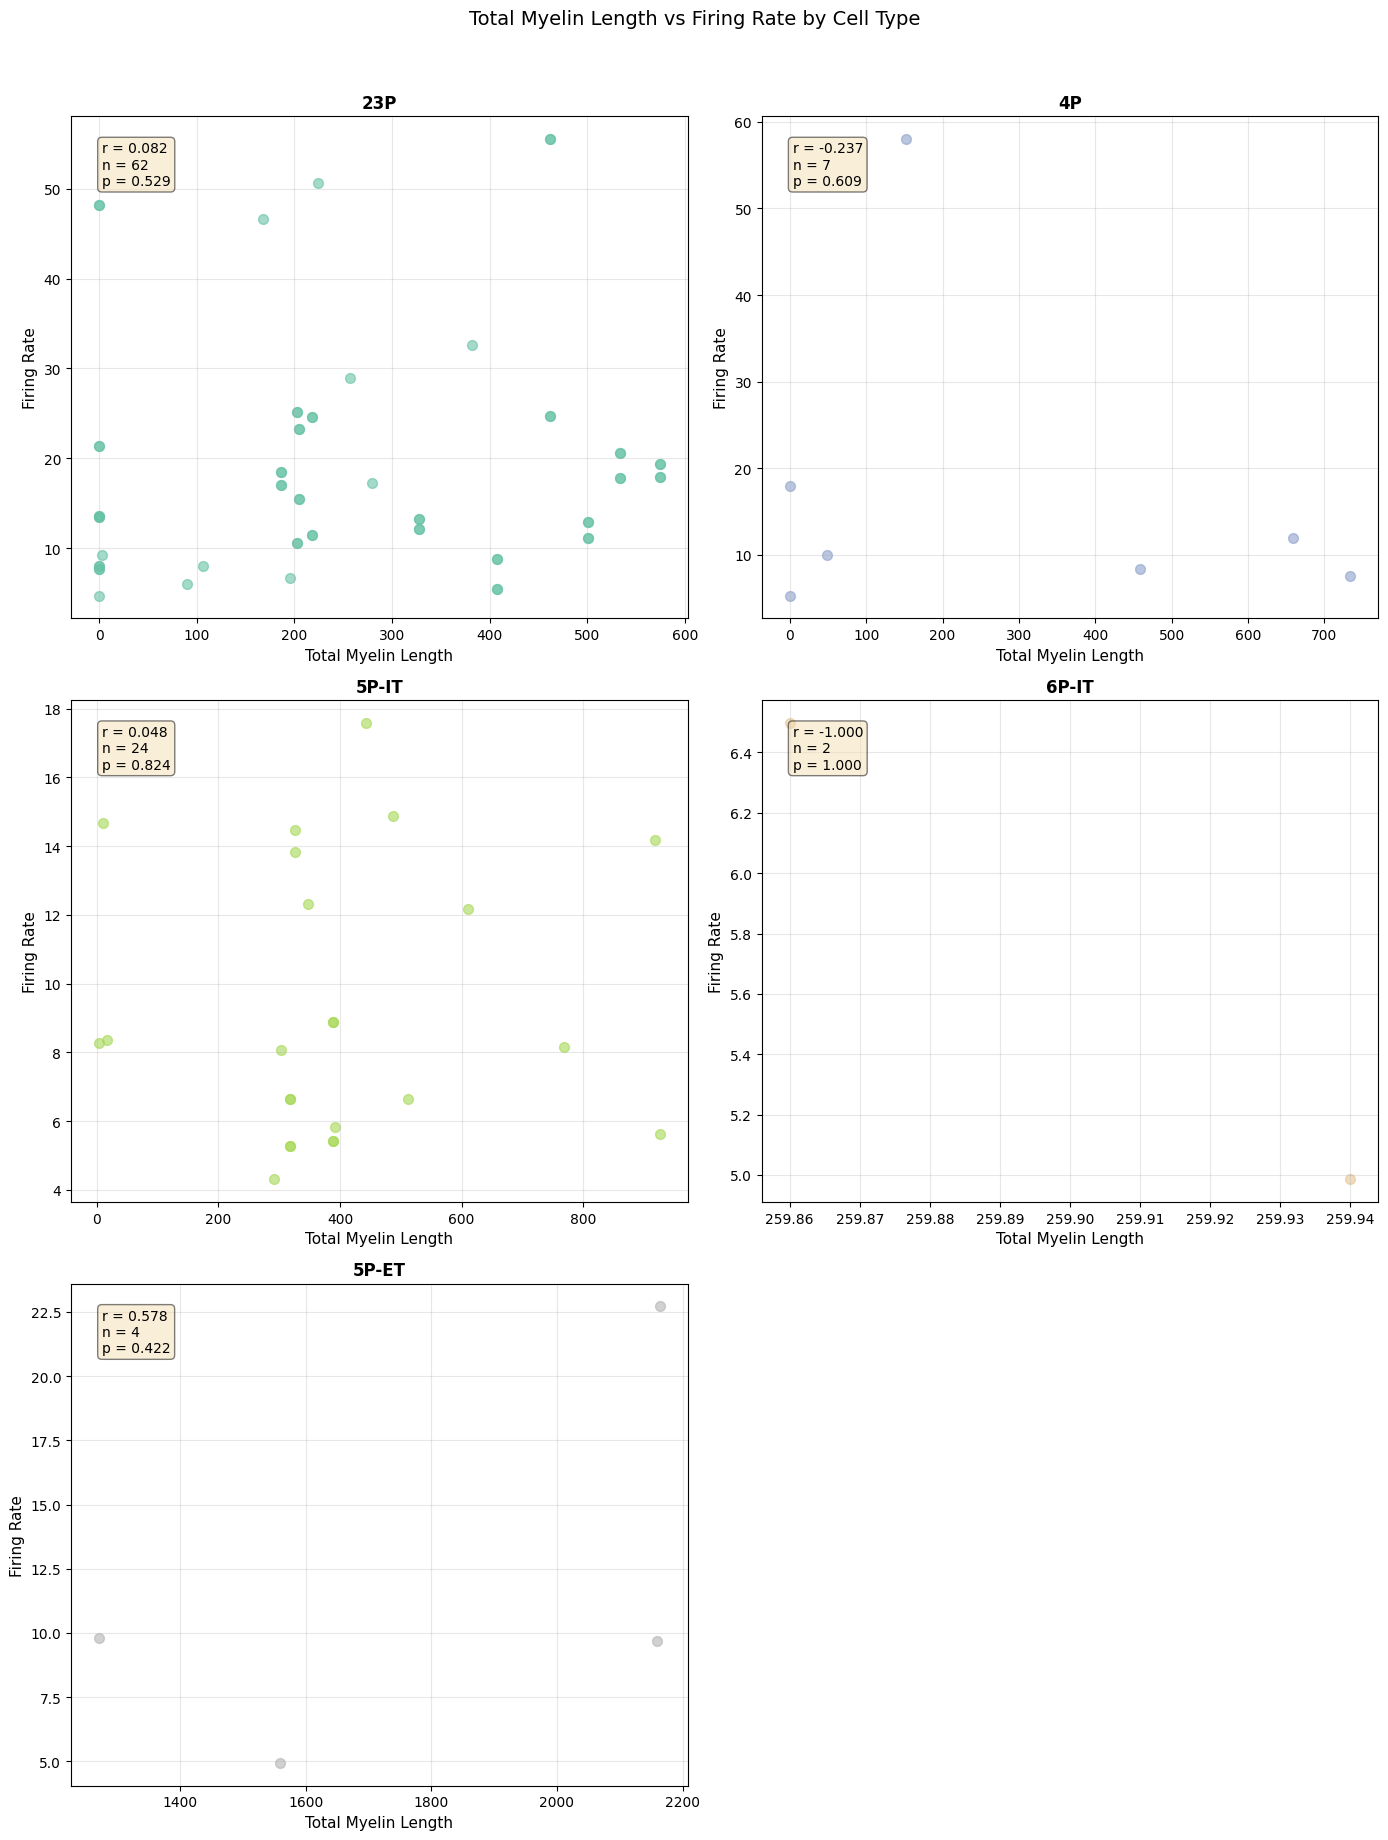

Detailed Statistics by Cell Type:

23P:
----------------------------------------
  Sample size: 62
  
Total Myelin Length:
    Mean: 260.70
    Std Dev: 192.95
    Min: 0.00
    Max: 573.75
  
Firing Rate:
    Mean: 18.82
    Std Dev: 12.31
    Min: 4.73
    Max: 55.51
  
Correlation coefficient: 0.082
  P-value: 0.5285 (ns)

4P:
----------------------------------------
  Sample size: 7
  
Total Myelin Length:
    Mean: 293.17
    Std Dev: 317.83
    Min: 0.00
    Max: 733.67
  
Firing Rate:
    Mean: 17.03
    Std Dev: 18.51
    Min: 5.31
    Max: 57.99
  
Correlation coefficient: -0.237
  P-value: 0.6095 (ns)

5P-IT:
----------------------------------------
  Sample size: 24
  
Total Myelin Length:
    Mean: 395.83
    Std Dev: 234.56
    Min: 3.60
    Max: 925.44
  
Firing Rate:
    Mean: 9.24
    Std Dev: 3.94
    Min: 4.31
    Max: 17.59
  
Correlation coefficient: 0.048
  P-value: 0.8244 (ns)

6P-IT:
----------------------------------------
  Sample size: 2
  
Total Myelin Length

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv('neuron_ids_activity.csv')

# Get unique cell types
cell_types = df['cell_type'].unique()
n_types = len(cell_types)

# Determine subplot layout
n_cols = 2 if n_types > 1 else 1
n_rows = (n_types + 1) // 2 if n_types > 1 else 1

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))

# If only one cell type, make axes a list for consistency
if n_types == 1:
    axes = [axes]
elif n_types == 2:
    axes = axes.flatten()
else:
    axes = axes.flatten()

# Create colors for each cell type
colors = plt.cm.Set2(np.linspace(0, 1, n_types))

# Plot for each cell type
for idx, cell_type in enumerate(cell_types):
    ax = axes[idx]
    
    # Filter data for this cell type
    cell_data = df[df['cell_type'] == cell_type]
    
    # Create scatter plot
    ax.scatter(cell_data['total_myelin_length'], 
               cell_data['firing_rate'], 
               alpha=0.6, 
               s=50, 
               color=colors[idx])
    
    # Add labels and title
    ax.set_xlabel('Total Myelin Length', fontsize=11)
    ax.set_ylabel('Firing Rate', fontsize=11)
    ax.set_title(f'{cell_type}', fontsize=12, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Calculate and display correlation on the plot
    correlation, p_value = stats.pearsonr(cell_data['total_myelin_length'], 
                                           cell_data['firing_rate'])
    # correlation = cell_data['total_myelin_length'].corr(cell_data['firing_rate'])
    ax.text(0.05, 0.95, f'r = {correlation:.3f}\nn = {len(cell_data)}\np = {p_value:.3f}', 
            transform=ax.transAxes, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide any extra subplots if odd number of cell types
if n_types % 2 == 1 and n_types > 1:
    axes[-1].set_visible(False)

# Add overall title
fig.suptitle('Total Myelin Length vs Firing Rate by Cell Type', fontsize=14, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

# Print detailed statistics for each cell type
print("Detailed Statistics by Cell Type:")
print("=" * 60)

for cell_type in cell_types:
    cell_data = df[df['cell_type'] == cell_type]
    print(f"\n{cell_type}:")
    print("-" * 40)
    print(f"  Sample size: {len(cell_data)}")
    print(f"  \nTotal Myelin Length:")
    print(f"    Mean: {cell_data['total_myelin_length'].mean():.2f}")
    print(f"    Std Dev: {cell_data['total_myelin_length'].std():.2f}")
    print(f"    Min: {cell_data['total_myelin_length'].min():.2f}")
    print(f"    Max: {cell_data['total_myelin_length'].max():.2f}")
    print(f"  \nFiring Rate:")
    print(f"    Mean: {cell_data['firing_rate'].mean():.2f}")
    print(f"    Std Dev: {cell_data['firing_rate'].std():.2f}")
    print(f"    Min: {cell_data['firing_rate'].min():.2f}")
    print(f"    Max: {cell_data['firing_rate'].max():.2f}")
    correlation, p_value = stats.pearsonr(cell_data['total_myelin_length'], 
                                           cell_data['firing_rate'])
    print(f"  \nCorrelation coefficient: {correlation:.3f}")
    if p_value < 0.001:
        print(f"  P-value: < 0.001 ***")
    elif p_value < 0.01:
        print(f"  P-value: {p_value:.4f} **")
    elif p_value < 0.05:
        print(f"  P-value: {p_value:.4f} *")
    else:
        print(f"  P-value: {p_value:.4f} (ns)")

print("\n" + "=" * 60)

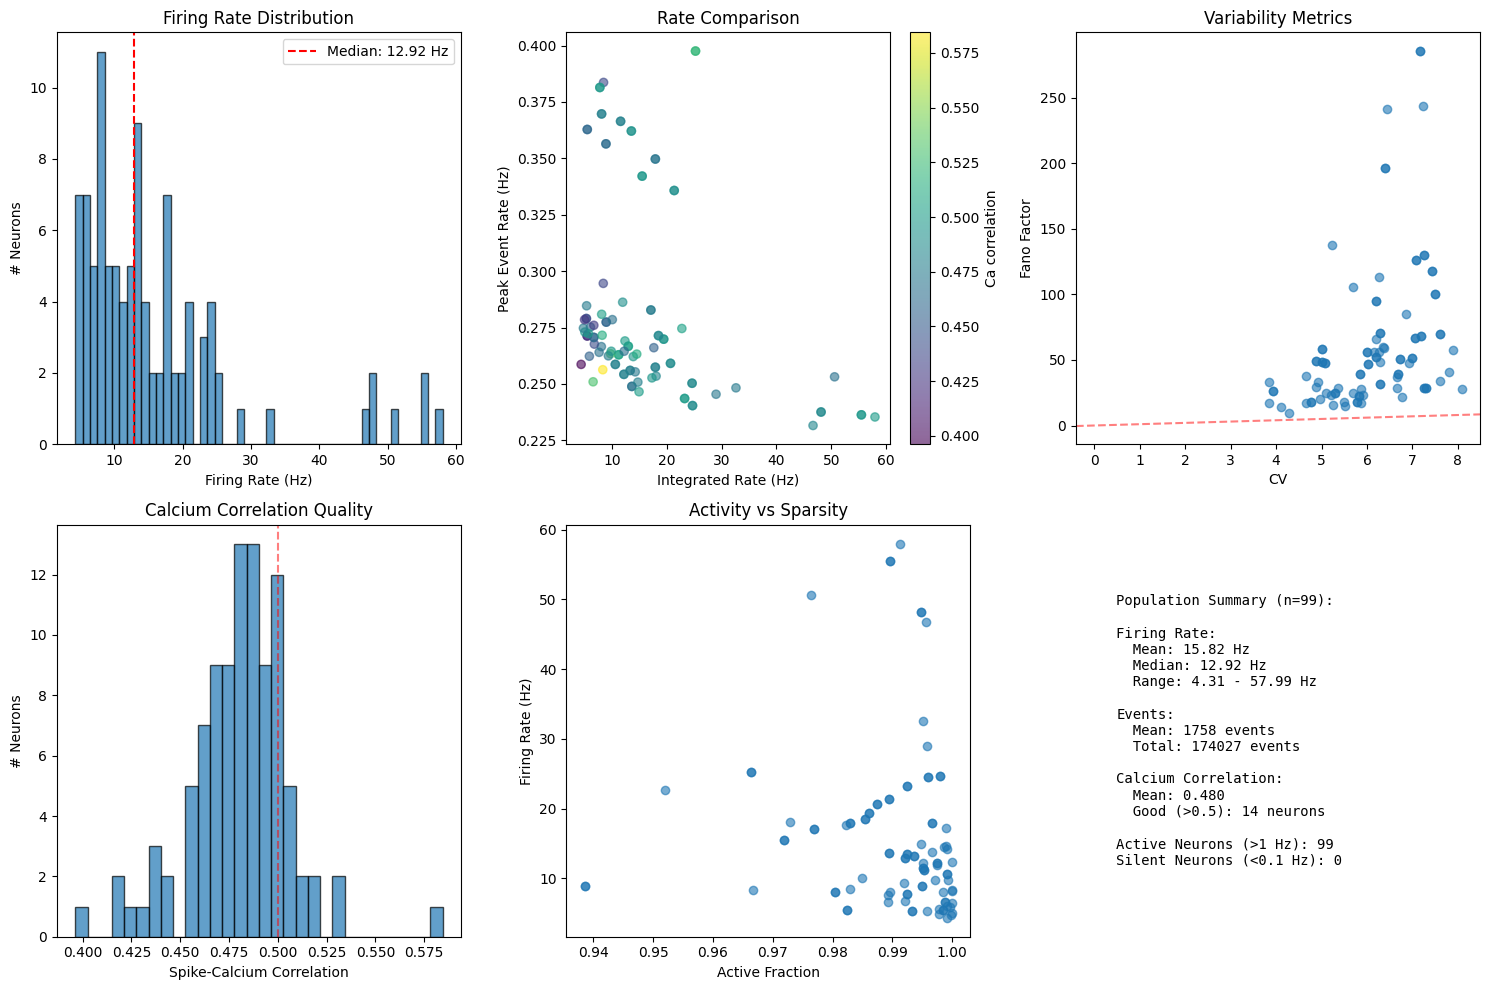

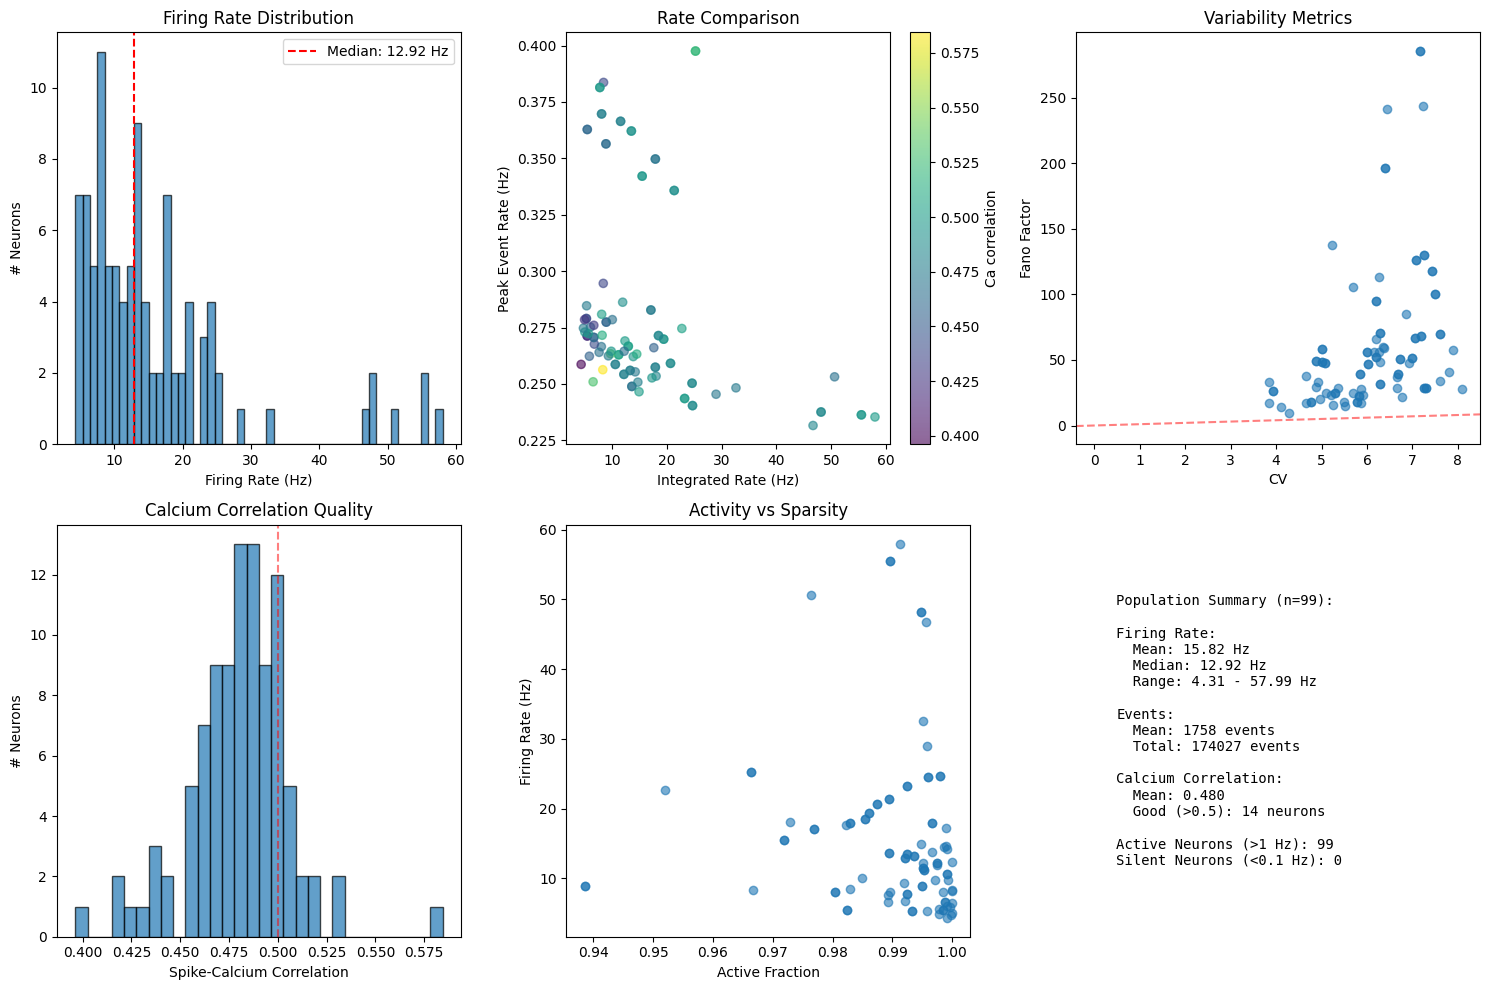

In [22]:
plot_population_summary(myelin_results_df)

In [7]:
# Get all unit keys
unit_entries = (nda.ScanUnit * nda.Activity).fetch('session', 'scan_idx', 'unit_id', as_dict=True)

# Count them
print(f"Total unit_keys: {len(unit_entries)}")

Total unit_keys: 168971


In [7]:
import pandas as pd

def quantify_neuron(unit_key, nda):
    """Quantify activity for a single neuron."""
    try:
        # Fetch data
        nframes, fps = (nda.Scan & unit_key).fetch1('nframes', 'fps')
        spike_trace = (nda.Activity & unit_key).fetch1('trace')
        calcium_trace = (nda.ScanUnit * nda.Fluorescence & unit_key).fetch1('trace')

        return {
            'session': unit_key['session'],
            'scan_idx': unit_key['scan_idx'],
            'unit_id': unit_key['unit_id'],
            'nframes': float(nframes),
            'fps': float(fps),
            'spike_trace': spike_trace,
            'calcium_trace': calcium_trace
        }
    except Exception as e:
        print(f"Error with {unit_key}: {e}")
        return None

def quantify_all_neurons(nda):
    """Loop through all unit_keys and save results."""
    # Build all unit keys (session, scan_idx, unit_id)
    unit_entries = (nda.ScanUnit * nda.Activity).fetch('session', 'scan_idx', 'unit_id', as_dict=True)

    results = []
    for entry in unit_entries:
        res = quantify_neuron(entry, nda)
        if res is not None:
            results.append(res)

    return results

# # Example usage
# results = quantify_all_neurons(nda)

# # Convert to DataFrame for easy saving
# df = pd.DataFrame(results)

# # Save to disk (traces may need separate handling if they are large tensors)
# df.to_pickle("neurons.pkl")   # preserves tensors
# df.drop(['spike_trace', 'calcium_trace'], axis=1).to_csv("neurons_summary.csv", index=False)

In [32]:
import random
import pandas as pd

def test_quantify_neurons(nda, n_test=10, seed=42):
    """Run quantify_neuron on a random sample of neurons."""
    # Fetch all unit_keys
    unit_entries = (nda.ScanUnit * nda.Activity).fetch('session', 'scan_idx', 'unit_id', as_dict=True)
    
    # Sample 100 neurons (or fewer if not enough)
    random.seed(seed)
    sample_entries = random.sample(unit_entries, min(n_test, len(unit_entries)))
    
    results = []
    for entry in sample_entries:
        res = quantify_neuron(entry, nda)
        if res is not None:
            results.append(res)

    # Convert to DataFrame for inspection
    df = pd.DataFrame(results)
    return df

# Example usage:
test_df = test_quantify_neurons(nda, n_test=10)
print(test_df.head())
print(f"Collected {len(test_df)} neurons")

test_df.to_pickle("test_neurons.pkl")

   session  scan_idx  unit_id  nframes      fps  \
0        9         6     4158  57000.0  9.62246   
1        5         3     2484  40000.0  6.30090   
2        4         7     6557  40000.0  6.30090   
3        6         6      909  40000.0  6.30090   
4        6         4     1834  40000.0  6.30090   

                                         spike_trace  \
0  [5.09575e-09, 5.207706e-09, 6.421042e-09, 5.22...   
1  [2.6791078e-09, 1.6566433e-09, 1.5280469e-09, ...   
2  [8.4291585e-08, 3.6883884e-07, 1.6103663e-06, ...   
3  [5.93655e-08, 8.323816e-08, 1.428604e-07, 2.00...   
4  [8.568882e-08, 1.4540801e-07, 4.788846e-07, 1....   

                                       calcium_trace  
0  [75.933754, 41.2299, 75.68741, 75.91259, 58.74...  
1  [35.362114, -2.3963914, 27.818604, 16.083572, ...  
2  [61.736504, 97.490036, 93.09682, 137.77727, 16...  
3  [41.311443, 26.362705, 41.21752, 58.729263, 31...  
4  [25.881012, 17.539034, 21.063814, 33.688904, 4...  
Collected 10 neurons


In [8]:
# unique natural videos

# Fetch all trial types
trial_types = (nda.Trial).fetch('type')

# Get unique values
unique_types = set(trial_types)

print(f"Found {len(unique_types)} unique stimulus types:")
for t in sorted(unique_types):
    print("-", t)

Found 3 unique stimulus types:
- stimulus.Clip
- stimulus.Monet2
- stimulus.Trippy


In [38]:
nda.Trial

microns_phase3.nda.Trial

In [37]:
valid_scans = (nda.Trial & {'type': 'stimulus.Clip'}).fetch('session', 'scan_idx', as_dict=True)

# Deduplicate (since multiple trials belong to the same scan)
valid_scans = { (d['session'], d['scan_idx']) for d in valid_scans }

print(f"Keeping {len(valid_scans)} scans with type=stimulus.Clip")

Keeping 19 scans with type=stimulus.Clip


In [23]:
nda.Trial & scan_key

/usr/local/lib/python3.9/site-packages/datajoint/connection.py:219: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")


session Session ID,scan_idx Scan ID,trial_idx index of trial within stimulus,type type of stimulus trial,start_idx index of field 1 scan frame at start of trial,end_idx index of field 1 scan frame at end of trial,start_frame_time start time of stimulus frame relative to scan start (seconds),end_frame_time end time of stimulus frame relative to scan start (seconds),stim_times full vector of stimulus frame times relative to scan start (seconds),condition_hash 120-bit hash (The first 20 chars of MD5 in base64)
4,7,0,stimulus.Clip,55,117,8.7030508518219,18.66956400871277,=BLOB=,JEL5/i5FccX4ykUOKaDW
4,7,1,stimulus.Clip,118,181,18.76955008506775,28.736061811447144,=BLOB=,AAQ1HNKGrg1cIXlMw7nz
4,7,2,stimulus.Clip,182,244,28.83605670928955,38.80255699157715,=BLOB=,ksTS42zV+O0YJqa0+s4Y
4,7,3,stimulus.Clip,245,308,38.90255165100098,48.869056224823,=BLOB=,m5JLObtSRnbRKw1ukcSE
4,7,4,stimulus.Clip,309,371,48.9690465927124,58.93554878234863,=BLOB=,L8Z/mji+v1WipuJe4GaL
4,7,5,stimulus.Clip,372,434,59.0355486869812,69.00203704833984,=BLOB=,3+VHi96yg36hu1kI8ZBn
4,7,6,stimulus.Monet2,435,529,69.11870193481445,84.10179495811462,=BLOB=,DKYV7TrfEl+C8nvadH+1
4,7,7,stimulus.Monet2,530,624,84.18511772155762,99.16820192337036,=BLOB=,+rgSVBVRE8Ij1WNhq8ZW
4,7,8,stimulus.Monet2,625,719,99.25153255462646,114.23461866378784,=BLOB=,GHn0W57E+2PS+Qr5yD2r
4,7,9,stimulus.Monet2,720,814,114.31795263290405,129.30104398727417,=BLOB=,u0ftbdrw9UHzSHDe1o4f


In [24]:
# Get the last 10 trials for this scan, ordered by trial_idx
tail_trials = (nda.Trial & scan_key).fetch(
    order_by='trial_idx DESC', limit=10, as_dict=True
)

# Reverse to show in ascending order
tail_trials = list(reversed(tail_trials))

for t in tail_trials:
    print(t)

{'session': 4, 'scan_idx': 7, 'trial_idx': 454, 'type': 'stimulus.Clip', 'start_idx': 31230, 'end_idx': 31293, 'start_frame_time': 4958.420427560806, 'end_frame_time': 4968.386913061142, 'stim_times': array([[4958.42042756, 4958.45375872, 4958.48709369, 4958.52042484,
        4958.55374503, 4958.58708787, 4958.62041616, 4958.6537559 ,
        4958.68708897, 4958.72041678, 4958.75375581, 4958.78707504,
        4958.82041621, 4958.85374212, 4958.88707399, 4958.9204061 ,
        4958.95374799, 4958.98707318, 4959.02040505, 4959.05374312,
        4959.08707809, 4959.1204052 , 4959.15373707, 4959.18707299,
        4959.22040701, 4959.25373912, 4959.2870791 , 4959.32039905,
        4959.35373116, 4959.38707399, 4959.42040014, 4959.45373917,
        4959.48706913, 4959.52040792, 4959.55373693, 4959.58707309,
        4959.62039304, 4959.65373707, 4959.68706298, 4959.72039413,
        4959.75372982, 4959.78706598, 4959.8204    , 4959.85373306,
        4959.88706398, 4959.92039609, 4959.95372796

In [25]:
import pandas as pd
import pickle

# Fetch the full Trial table for this scan
trial_df = pd.DataFrame((nda.Trial & scan_key).fetch())

# Save to pickle
trial_outfile = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_trials.pkl"
trial_df.to_pickle(trial_outfile)

print(f"Saved {len(trial_df)} trials to {trial_outfile}")

/usr/local/lib/python3.9/site-packages/datajoint/connection.py:219: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")


Saved 464 trials to scan_4_7_trials.pkl


In [ ]:
# 1. Get the first scan (ordered)
# Get the first scan (ordered by session, scan_idx)
first_scan = (nda.Scan).fetch('session', 'scan_idx', order_by='session, scan_idx', limit=1, as_dict=True)[0]

scan_key = dict(session=first_scan['session'], scan_idx=first_scan['scan_idx'])
print("Processing scan:", scan_key)

# 2. Get unit keys for that scan
unit_entries = (nda.ScanUnit * nda.Activity & scan_key).fetch(
    'session', 'scan_idx', 'unit_id', as_dict=True
)

# 3. Get Clip trials for that scan
clip_trials = (nda.Trial & scan_key & {'type': 'stimulus.Clip'}).fetch(
    'trial_idx', 'start_idx', 'end_idx', as_dict=True
)

print(f"Found {len(unit_entries)} units and {len(clip_trials)} Clip trials in this scan.")

Processing scan: {'session': 4, 'scan_idx': 7}


Found 8395 units and 384 Clip trials in this scan.


In [22]:
print(clip_trials)

[{'trial_idx': 0, 'start_idx': 55, 'end_idx': 117}, {'trial_idx': 1, 'start_idx': 118, 'end_idx': 181}, {'trial_idx': 2, 'start_idx': 182, 'end_idx': 244}, {'trial_idx': 3, 'start_idx': 245, 'end_idx': 308}, {'trial_idx': 4, 'start_idx': 309, 'end_idx': 371}, {'trial_idx': 5, 'start_idx': 372, 'end_idx': 434}, {'trial_idx': 10, 'start_idx': 815, 'end_idx': 878}, {'trial_idx': 11, 'start_idx': 879, 'end_idx': 941}, {'trial_idx': 12, 'start_idx': 942, 'end_idx': 1004}, {'trial_idx': 13, 'start_idx': 1005, 'end_idx': 1068}, {'trial_idx': 14, 'start_idx': 1069, 'end_idx': 1131}, {'trial_idx': 15, 'start_idx': 1132, 'end_idx': 1194}, {'trial_idx': 20, 'start_idx': 1575, 'end_idx': 1637}, {'trial_idx': 21, 'start_idx': 1638, 'end_idx': 1701}, {'trial_idx': 22, 'start_idx': 1702, 'end_idx': 1764}, {'trial_idx': 23, 'start_idx': 1765, 'end_idx': 1828}, {'trial_idx': 24, 'start_idx': 1829, 'end_idx': 1891}, {'trial_idx': 25, 'start_idx': 1892, 'end_idx': 1954}, {'trial_idx': 26, 'start_idx': 19

In [26]:
import pickle

# 4. Quantify neurons for this scan
results = []
for entry in unit_entries:
    res = quantify_neuron(entry, nda)
    if res is not None:
        # Optionally, attach the Clip trials info to each neuron
        # res['clip_trials'] = clip_trials
        results.append(res)

# 5. Save to pickle
out_file = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_clip.pkl"
with open(out_file, "wb") as f:
    pickle.dump(results, f)

print(f"Saved {len(results)} neurons to {out_file}")

KeyboardInterrupt: 

In [9]:
coregistration_df

,id_ref,created_ref,valid_ref,volume,pt_position_x,pt_position_y,pt_position_z,bb_start_position_x,bb_start_position_y,bb_start_position_z,...,id,created,valid,target_id,session,scan_idx,unit_id,field,residual,score
0,335649,1601332880303,t,295.861125,210784,182032,22673,None,None,None,...,5491,1716316705372,t,335649,6,2,6883,6,7.41244,2.60806
1,194144,1601332921511,t,213.307228,136400,170640,17951,None,None,None,...,12542,1716316960285,t,194144,7,4,9575,6,8.55708,-0.71490
2,194144,1601332921511,t,213.307228,136400,170640,17951,None,None,None,...,15097,1716316961703,t,194144,8,5,8632,6,4.25055,7.87525
3,517966,1601332908288,t,313.318932,310944,115888,16752,None,None,None,...,12829,1716316960443,t,517966,7,5,1526,2,5.82370,4.16608
4,293318,1601333123572,t,430.108180,189472,119296,26037,None,None,None,...,18299,1716316963440,t,293318,9,4,8066,6,5.63758,8.91502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19176,187704,1601333005854,t,280.180654,141728,109920,24481,None,None,None,...,6098,1716316705717,t,187704,6,4,1973,2,13.46900,-8.02714
19177,432639,1601333125114,t,471.135846,249632,193648,22635,None,None,None,...,11239,1716316959579,t,432639,7,3,9049,8,3.66317,8.00223
19178,269593,1601333010133,t,317.925458,172464,221888,23253,None,None,None,...,4356,1716316704733,t,269593,5,7,8524,8,6.45214,9.54236
19179,269402,1601332902679,t,311.959552,172480,211312,21821,None,None,None,...,10086,1716316958950,t,269402,6,7,8235,8,7.12704,12.27556


In [ ]:
# 2. Get the list of unit_ids from your coregistration_df for this scan
unit_ids = coregistration_df[
    (coregistration_df['session'] == scan_key['session']) &
    (coregistration_df['scan_idx'] == scan_key['scan_idx'])
]['unit_id'].unique().tolist()

print(f"Found {len(unit_ids)} unit_ids in coregistration_df for scan {scan_key}")

# 3. Restrict the activity table to only those unit_ids
unit_entries = (nda.ScanUnit * nda.Activity & scan_key & f'unit_id in {tuple(unit_ids)}').fetch(
    'session', 'scan_idx', 'unit_id', as_dict=True
)

print(f"Pulled {len(unit_entries)} activity entries")

Found 1322 unit_ids in coregistration_df for scan {'session': 4, 'scan_idx': 7}
Pulled 1322 activity entries


In [ ]:
import pickle

# 4. Quantify neurons for this scan
results = []
for entry in unit_entries:
    res = quantify_neuron(entry, nda)
    if res is not None:
        # Optionally, attach the Clip trials info to each neuron
        # res['clip_trials'] = clip_trials
        results.append(res)

# 5. Save to pickle
out_file = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_coreg.pkl"
with open(out_file, "wb") as f:
    pickle.dump(results, f)

print(f"Saved {len(results)} neurons to {out_file}")

Saved 1322 neurons to scan_4_7_coreg.pkl


In [ ]:
import os
import pickle
import math
import zipfile

# Folder to save results
out_dir = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_coreg"
os.makedirs(out_dir, exist_ok=True)

# Split into chunks of 100 neurons
chunk_size = 100
n_chunks = math.ceil(len(results) / chunk_size)

for i in range(n_chunks):
    chunk = results[i*chunk_size : (i+1)*chunk_size]
    out_file = os.path.join(out_dir, f"neurons_{i*chunk_size:05d}_{(i+1)*chunk_size-1:05d}.pkl")
    with open(out_file, "wb") as f:
        pickle.dump(chunk, f)
    print(f"Saved {len(chunk)} neurons → {out_file}")

# Zip the whole folder
zip_file = f"{out_dir}.zip"
with zipfile.ZipFile(zip_file, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(out_dir):
        for file in files:
            zipf.write(os.path.join(root, file),
                       arcname=os.path.relpath(os.path.join(root, file), out_dir))

print(f"Zipped all chunks into {zip_file}")

Saved 100 neurons → scan_4_7_coreg/neurons_00000_00099.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00100_00199.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00200_00299.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00300_00399.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00400_00499.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00500_00599.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00600_00699.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00700_00799.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00800_00899.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_00900_00999.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_01000_01099.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_01100_01199.pkl
Saved 100 neurons → scan_4_7_coreg/neurons_01200_01299.pkl
Saved 22 neurons → scan_4_7_coreg/neurons_01300_01399.pkl
Zipped all chunks into scan_4_7_coreg.zip


In [8]:
import os
import pickle
import zipfile

# 1. Get all scans
all_scans = (nda.Scan).fetch('session', 'scan_idx', order_by='session, scan_idx', as_dict=True)

for scan_key in all_scans:
    out_dir = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_coreg"
    zip_file = f"{out_dir}.zip"

    # ✅ Skip if zip already exists
    if os.path.exists(zip_file):
        print(f"Skipping {scan_key} → {zip_file} already exists.")
        continue


    print(f"Processing scan: {scan_key}")

    # 2. Get unit_ids from coregistration_df for this scan
    unit_ids = coregistration_df[
        (coregistration_df['session'] == scan_key['session']) &
        (coregistration_df['scan_idx'] == scan_key['scan_idx'])
    ]['unit_id'].unique().tolist()

    if len(unit_ids) == 0:
        print(f"⚠️ No unit_ids found in coregistration_df for {scan_key}, skipping.")
        continue

    print(f"  Found {len(unit_ids)} unit_ids")

    # 3. Restrict activity to those unit_ids
    unit_entries = (nda.ScanUnit * nda.Activity & scan_key & f'unit_id in {tuple(unit_ids)}').fetch(
        'session', 'scan_idx', 'unit_id', as_dict=True
    )

    print(f"  Pulled {len(unit_entries)} activity entries")

    # 4. Make output folder for this scan
    out_dir = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_coreg"
    os.makedirs(out_dir, exist_ok=True)

    # 5. Process each neuron and save individually
    for entry in unit_entries:
        res = quantify_neuron(entry, nda)
        if res is not None:
            unit_id = entry['unit_id']
            out_file = os.path.join(out_dir, f"unit_{unit_id}.pkl")
            with open(out_file, "wb") as f:
                pickle.dump(res, f)
            # Or: res.to_pickle(out_file) if res is a DataFrame
            print(f"    Saved neuron {unit_id} → {out_file}")

    # 6. Zip the whole folder
    zip_file = f"{out_dir}.zip"
    with zipfile.ZipFile(zip_file, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(out_dir):
            for file in files:
                zipf.write(os.path.join(root, file),
                           arcname=os.path.relpath(os.path.join(root, file), out_dir))

    print(f"  Zipped folder → {zip_file}")

Skipping {'session': 4, 'scan_idx': 7} → scan_4_7_coreg.zip already exists.
Processing scan: {'session': 4, 'scan_idx': 9}
⚠️ No unit_ids found in coregistration_df for {'session': 4, 'scan_idx': 9}, skipping.
Processing scan: {'session': 4, 'scan_idx': 10}
⚠️ No unit_ids found in coregistration_df for {'session': 4, 'scan_idx': 10}, skipping.
Skipping {'session': 5, 'scan_idx': 3} → scan_5_3_coreg.zip already exists.
Skipping {'session': 5, 'scan_idx': 6} → scan_5_6_coreg.zip already exists.
Skipping {'session': 5, 'scan_idx': 7} → scan_5_7_coreg.zip already exists.
Skipping {'session': 6, 'scan_idx': 2} → scan_6_2_coreg.zip already exists.
Skipping {'session': 6, 'scan_idx': 4} → scan_6_4_coreg.zip already exists.
Skipping {'session': 6, 'scan_idx': 6} → scan_6_6_coreg.zip already exists.
Skipping {'session': 6, 'scan_idx': 7} → scan_6_7_coreg.zip already exists.
Skipping {'session': 7, 'scan_idx': 3} → scan_7_3_coreg.zip already exists.
Skipping {'session': 7, 'scan_idx': 4} → scan_

In [9]:
import pandas as pd
import pickle

for scan_key in all_scans:
    # Fetch the full Trial table for this scan
    trial_df = pd.DataFrame((nda.Trial & scan_key).fetch())

    # Save to pickle
    trial_outfile = f"scan_{scan_key['session']}_{scan_key['scan_idx']}_trials.pkl"
    trial_df.to_pickle(trial_outfile)

    print(f"Saved {len(trial_df)} trials to {trial_outfile}")

Saved 464 trials to scan_4_7_trials.pkl
Saved 464 trials to scan_4_9_trials.pkl
Saved 464 trials to scan_4_10_trials.pkl
Saved 464 trials to scan_5_3_trials.pkl
Saved 464 trials to scan_5_6_trials.pkl
Saved 464 trials to scan_5_7_trials.pkl
Saved 464 trials to scan_6_2_trials.pkl
Saved 464 trials to scan_6_4_trials.pkl
Saved 464 trials to scan_6_6_trials.pkl
Saved 464 trials to scan_6_7_trials.pkl
Saved 464 trials to scan_7_3_trials.pkl
Saved 464 trials to scan_7_4_trials.pkl
Saved 464 trials to scan_7_5_trials.pkl
Saved 464 trials to scan_8_5_trials.pkl
Saved 464 trials to scan_8_7_trials.pkl
Saved 464 trials to scan_8_9_trials.pkl
Saved 464 trials to scan_9_3_trials.pkl
Saved 464 trials to scan_9_4_trials.pkl
Saved 464 trials to scan_9_6_trials.pkl
